# Bases de datos

### Etapa Regular

In [1]:
import pandas as pd
import pyreadstat
import os
import numpy as np

In [2]:
os.chdir("/Users/cristianmolina/Desktop/Proyectos MINEDU 2026 - Github/Investigacion_EDDIR_IE_2024/outputs")

In [3]:
BD, meta = pyreadstat.read_sav("/Users/cristianmolina/Desktop/Proyectos MINEDU 2026 - Github/Investigacion_EDDIR_IE_2024/inputs/Consolidado_EDDirIE2024_08-03.sav")
BD2 = BD.copy()
BD2["sex"] = np.where(BD2["sex"]==1, "Masculino", "Femenino")

In [4]:
# Filtro poblacional
BD2 = BD2[(BD2["ESTADODEEVALUACIÓN"].isin(["APROBADO", "DESAPROBADO", "PENDIENTE"])) &
          ~(BD2["Condicion3"].isin(["No cumple"]))
          ]
# Perfil final del directivo
BD2["Tipo_Directivo"] = BD2["ModalidadEducativa"] + " " + BD2["DesTipDirectivo"] + " " + BD2["DesPerfil"]

BD2.loc[BD2["Tipo_Directivo"].str.startswith("EBR", na=False), "Tipo_Directivo"].value_counts(dropna=False)

Tipo_Directivo
EBR Director Sin función docente    2572
EBR Director Con función docente    1716
EBR Subdirector Ninguno              965
Name: count, dtype: int64

In [5]:
pd.crosstab(BD2[BD2["Tipo_Directivo"].str.startswith("EBR")]["ESTADODEEVALUACIÓN"],
            BD2[BD2["Tipo_Directivo"].str.startswith("EBR")]["Tipo_Directivo"], margins=True)

Tipo_Directivo,EBR Director Con función docente,EBR Director Sin función docente,EBR Subdirector Ninguno,All
ESTADODEEVALUACIÓN,,,,
APROBADO,1068,1512,475,3055
DESAPROBADO,12,34,7,53
PENDIENTE,636,1026,483,2145
All,1716,2572,965,5253


In [6]:
BD3 = BD2[(BD2["ModalidadEducativa"]=="EBR") &
(BD2["DesTipDirectivo"]=="Director") &   
(BD2["DesPerfil"]=="Sin función docente")]

BD4 = BD2[(BD2["ModalidadEducativa"]=="EBR") &
(BD2["DesTipDirectivo"]=="Director") &   
(BD2["DesPerfil"]=="Con función docente")]

BD5 = BD2[(BD2["ModalidadEducativa"]=="EBR") &
(BD2["DesTipDirectivo"]=="Subdirector") &   
(BD2["DesPerfil"]=="Ninguno")]

print(BD3.shape)
print(BD4.shape)
print(BD5.shape)

(2572, 154)
(1716, 154)
(965, 154)


In [7]:
import pandas as pd

cols = [
    'D1S1','D1S2','D1S3','D1S4',
    'D2S5','D2S6','D2S7',
    'D3S8','D3S9','D3S10','D3S11'
]

resultado = (
    BD2[BD2["Tipo_Directivo"].str.startswith("EBR")]
    .groupby("Tipo_Directivo")[cols]
    .agg(["count",'mean','std', "median"])
    .T
    .round(2)
).reset_index()

resultado.to_excel("Tabla2.xlsx", index=False)

In [28]:
import pandas as pd

cols = [
    'D1S1','D1S2','D1S3','D1S4',
    'D2S5','D2S6','D2S7',
    'D3S8','D3S9','D3S10','D3S11'
]

# Filtrar EBR
df = BD2[BD2["Tipo_Directivo"].str.startswith("EBR")]

# Convertir a formato largo
df_long = df.melt(
    id_vars="Tipo_Directivo",
    value_vars=cols,
    var_name="Subdimension",
    value_name="Nivel"
)

# Conteo
conteo = (
    df_long
    .groupby(["Subdimension","Tipo_Directivo","Nivel"])
    .size()
    .reset_index(name="Frecuencia")
)

# Totales por grupo
totales = (
    conteo
    .groupby(["Subdimension","Tipo_Directivo"])["Frecuencia"]
    .transform("sum")
)

# Porcentaje
conteo["Porcentaje"] = (conteo["Frecuencia"] / totales) * 100

resultado = conteo.round(2)

resultado.to_excel("Distribucion_real.xlsx", index=False)

### Etapa excepcional

### Bases complementarias

#### Base maestra

In [7]:
BD_Maestra, meta2 = pyreadstat.read_sav(r"/Users/cristianmolina/Desktop/Proyectos MINEDU 2026 - Github/Investigacion_EDDIR_IE_2024/inputs/BM_postulantes_y_evaluaciones_08.01.2026_ultimo.sav")

In [8]:
BD_Maestra.drop_duplicates(subset="DNI", inplace=True)

In [9]:
BD_Maestra["LEY_PROCEDE_max2"] = np.select(
    [(BD_Maestra["LEY_PROCEDE_max"]==1),
     (BD_Maestra["LEY_PROCEDE_max"]==2),
     (BD_Maestra["LEY_PROCEDE_max"]==3)
     ],
    ["CPM", "PROF", "LRM"],
    default="-"
)

#### IDH

In [10]:
IDH = pd.read_excel(
    r"/Users/cristianmolina/Desktop/Proyectos MINEDU 2026 - Github/Investigacion_EDDIR_IE_2024/inputs/anexo_1-idh_2017-2024_a_nivel_distrital.xlsx", sheet_name="Hoja1",
    header=0, dtype={"UBIGEO":str}
)

In [11]:
IDH_distrital = IDH.loc[~IDH["UBIGEO"].str.endswith("00", na=False)]

#### Nexus nombrados 2024 - Julio

In [12]:
Nexus_nomb_Jul24, meta_nombrados_jul24 = pyreadstat.read_sav("/Users/cristianmolina/Desktop/Proyectos MINEDU 2026 - Github/Investigacion_EDDIR_IE_2024/inputs/Nexus_jul2024_nombrados.sav")

In [13]:
Nexus_nomb_Jul24["descargo"].value_counts(dropna=False).reset_index()["descargo"].to_list()

['PROFESOR',
 'DIRECTOR I.E.',
 'SUB-DIRECTOR I.E.',
 'PROFESOR - EDUCACION FISICA',
 'PROFESOR - IP',
 'ESPECIALISTA EN EDUCACION',
 'PROFESOR COORDINADOR',
 'JEFE DE LABORATORIO',
 'COORDINADOR PEDAGOGICO',
 'COORDINADOR DE TUTORIA Y ORIENTACION EDUCATIVA',
 'JEFE DE TALLER',
 'DIRECTOR DE UNIDAD DE GESTIÓN EDUCATIVA LOCAL',
 'JEFE DE GESTIÓN PEDAGÓGICA',
 'COORDINADOR ACADEMICO',
 'ESPECIALISTA EN EDUCACION II',
 'DOCENTE COORDINADOR',
 'DIRECTOR DE GESTIÓN PEDAGÓGICA',
 'PROFESOR - AIP',
 'PROFESOR (TECNICO DEPORTIVO)',
 'ESPECIALISTA EN EDUCACION I',
 'DOCENTE BIBLIOTECARIO',
 'PROFESOR (PROMOTOR CULTURAL)',
 'ESPECIALISTA EN EDUCACION III',
 'COORDINADOR',
 'JEFE DE PRODUCCION',
 'JEFE DE TALLER DE ELECTRICIDAD',
 'JEFE DE CAMPO',
 'JEFE DE TALLER DE INDUSTRIA DEL VESTIDO',
 'JEFE DE AREA ADMINISTRATIVA',
 'JEFE DE TALLER DE CAMPO',
 'JEFE DE TALLER DE MECANICA DE PRODUCCION',
 'JEFE DE CAMPO AGROPECUARIO',
 'ESPECIALISTA EN EDUCACION IV',
 'DOCENTE ESTABLE',
 'JEFE DE AREA',
 'J

In [14]:
Nexus_nomb_Jul24_u = Nexus_nomb_Jul24[Nexus_nomb_Jul24["unicos"]==1]

Número de subdiretores por código modular

In [15]:
Subdirectores_julio2024 = Nexus_nomb_Jul24[Nexus_nomb_Jul24["descargo"]=="SUB-DIRECTOR I.E."].groupby("codmodce")["DNI"].count().reset_index()

#### Habilitados - DITEN

In [16]:
Habilitados = pd.read_excel("/Users/cristianmolina/Desktop/Proyectos MINEDU 2026 - Github/Investigacion_EDDIR_IE_2024/inputs/Habilitados_fuenteDITEN25032024_080424_6606_actualizado230524_vf.xlsx",
                            dtype={"DNI":str, "COD_MOD_diten":str, 
                                   "CODPLAZA_":str, "COD_MOD":str,
                                   "CODLOCAL":str                                   
                                   })

In [17]:
Habilitados["TipodeRuralidad"] = np.where(Habilitados["TipodeRuralidad"].isna(), "No Rural", 
                                             Habilitados["TipodeRuralidad"]
                                             )

In [18]:
Habilitados_v2= Habilitados[["DNI", "CODPLAZA_", "COD_MOD_diten", "CODINST", "COD_MOD", "CODLOCAL", 
             "d_cod_car", "d_gestion", "dareacenso", "TipodeInstituciónEducativa",
             "TipodeRuralidad", "zona_frontera", "zona_vraem", "talumno"
             ]]

In [19]:
Habilitados_v2["TipodeRuralidad"] = np.where(Habilitados_v2["TipodeRuralidad"].isna(), "No Rural", 
                                             Habilitados_v2["TipodeRuralidad"]
                                             )

/var/folders/q0/g4lpgm596gsdglnm1whqqb580000gn/T/ipykernel_55050/3050376623.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Habilitados_v2["TipodeRuralidad"] = np.where(Habilitados_v2["TipodeRuralidad"].isna(), "No Rural",


Numero de codigos modulares por DNI que pertenecen a Rural 1, Rural 2 o Rural 3

In [20]:
# 1) Filtrar solo Rural 1
df_r1 = Habilitados[Habilitados["TipodeRuralidad"] == "Rural 1"]

# 2) Contar codigos modulares por DNI
codmods_r1_por_dni = (
    df_r1.groupby("DNI")["COD_MOD"]
    .count()
    .reset_index()
    .rename(columns={"COD_MOD": "n_codmods_R1"})
)

# 1) Filtrar solo Rural 2
df_r2 = Habilitados[Habilitados["TipodeRuralidad"] == "Rural 2"]

# 2) Contar codigos modulares por DNI
codmods_r2_por_dni = (
    df_r2.groupby("DNI")["COD_MOD"]
    .count()
    .reset_index()
    .rename(columns={"COD_MOD": "n_codmods_R2"})
)

# 1) Filtrar solo Rural 3
df_r3 = Habilitados[Habilitados["TipodeRuralidad"] == "Rural 3"]

# 2) Contar codigos modulares por DNI
codmods_r3_por_dni = (
    df_r3.groupby("DNI")["COD_MOD"]
    .count()
    .reset_index()
    .rename(columns={"COD_MOD": "n_codmods_R3"})
)

Numero de alumnos por DNI desde la base de habilitados

In [21]:
Alumnas_DNI = Habilitados.groupby("DNI")["talumno"].mean().reset_index()

#### Nexus contratados 2024 - Julio

In [23]:
Nexus_contratados_Jul24, metacontra24 = pyreadstat.read_sav("/Users/cristianmolina/Desktop/Proyectos MINEDU 2026 - Github/Investigacion_EDDIR_IE_2024/inputs/Nexus_jul2024_contratados.sav")

In [24]:
Nexus_contratados_Jul24["descargo"].value_counts(dropna=False).reset_index()["descargo"].to_list()

['PROFESOR',
 'PROFESOR - EDUCACION FISICA',
 'PROFESOR - IP',
 'PROFESOR COORDINADOR',
 'PROFESOR (TECNICO DEPORTIVO)',
 'PROFESOR (PROMOTOR CULTURAL)',
 'DOCENTE COORDINADOR',
 'COORDINADOR PRONOEI',
 'PROMOTOR ARTISTICO',
 'DOCENTE BIBLIOTECARIO']

In [25]:
Contratados_unicos_codmodce = Nexus_contratados_Jul24[Nexus_contratados_Jul24["unicos"]==1].groupby("codmodce")["DNI"].count().reset_index()

#### Nexus total

In [26]:
Nexus_Jul24, meta_nexu_jul24 = pyreadstat.read_sav("/Users/cristianmolina/Desktop/Proyectos MINEDU 2026 - Github/Investigacion_EDDIR_IE_2024/inputs/Nexus_jul2024.sav")

In [27]:
Lista_cargos_educacion = ['PROFESOR',
 'DIRECTOR I.E.',
 'SUB-DIRECTOR I.E.',
 'PROFESOR - EDUCACION FISICA',
 'PROFESOR - IP',
 'ESPECIALISTA EN EDUCACION',
 'PROFESOR COORDINADOR',
 'JEFE DE LABORATORIO',
 'COORDINADOR PEDAGOGICO',
 'COORDINADOR DE TUTORIA Y ORIENTACION EDUCATIVA',
 'JEFE DE TALLER',
 'DIRECTOR DE UNIDAD DE GESTIÓN EDUCATIVA LOCAL',
 'JEFE DE GESTIÓN PEDAGÓGICA',
 'COORDINADOR ACADEMICO',
 'ESPECIALISTA EN EDUCACION II',
 'DOCENTE COORDINADOR',
 'DIRECTOR DE GESTIÓN PEDAGÓGICA',
 'PROFESOR - AIP',
 'PROFESOR (TECNICO DEPORTIVO)',
 'ESPECIALISTA EN EDUCACION I',
 'DOCENTE BIBLIOTECARIO',
 'PROFESOR (PROMOTOR CULTURAL)',
 'ESPECIALISTA EN EDUCACION III',
 'COORDINADOR',
 'JEFE DE PRODUCCION',
 'JEFE DE TALLER DE ELECTRICIDAD',
 'JEFE DE CAMPO',
 'JEFE DE TALLER DE INDUSTRIA DEL VESTIDO',
 'JEFE DE AREA ADMINISTRATIVA',
 'JEFE DE TALLER DE CAMPO',
 'JEFE DE TALLER DE MECANICA DE PRODUCCION',
 'JEFE DE CAMPO AGROPECUARIO',
 'ESPECIALISTA EN EDUCACION IV',
 'DOCENTE ESTABLE',
 'JEFE DE AREA',
 'JEFE DE TALLER DE COMPUTACION E INFORMATICA',
 'JEFE DE TALLER DE ELECTRONICA',
 'ESPECIALISTA ADMINISTRATIVO III',
 'SUB-DIRECTOR DE EDUCACION PRIMARIA',
 'PROFESOR (EDUCACION A DISTANCIA)',
 'COORDINADOR ODEC',
 'COORDINADOR A.D.E.',
 'JEFE DE DEPARTAMENTO',
 'JEFE DE DPTO. COMPUTACION E INFORMATICA',
 'COORDINADOR AREA TECNICA',
 'PROFESOR DE LABORATORIO',
 'JEFE DE MUSICA',
 'JEFE DE DPTO. ADMINISTRATIVO',
 'INSTRUCTOR',
 'JEFE DE AREA ACADEMICA DE EDUCACION SECUNDARIA',
 'PROMOTOR ARTISTICO',
 'ASESOR',
 'PROFESOR CON FUNCIONES DE COORDINADOR DE TUTORIA JEC',
 'JEFE DE AREA ACADEMICA DE EDUCACION ARTISTICA - MUSICA',
 'JEFE DE TALLER DE MECANICA',
 'JEFE DE TALLER MECANOGRAFIA / CONTABILIDAD',
 'PROFESOR (FUNCIONES DE DIRECTOR)',
 'JEFE DE AREA TECNICA',
 'COORDINADOR DE O.B.E.',
 'JEFE DE AREA ACADEMICA',
 'PROMOTOR DE CAMPO',
 'JEFE DE LABORATORIO - QUIMICA',
 'ESPECIALISTA EN EDUCACION PRIMARIA',
 'SUB-DIRECTOR DE AREAS TECNICAS',
 'SUPERVISOR DE EDUCACION RELIGIOSA',
 'JEFE DE TALLER DE CARPINTERIA',
 'ESPECIALISTA EN EDUCACION - TUTORIA Y CULTURA',
 'SUB-DIRECTOR DE FORMACION GENERAL',
 'ESPECIALISTA EN EDUCACION - PRIM. EBI Y PRIM. ADULT.',
 'PROFESOR',
 'PROFESOR - EDUCACION FISICA',
 'PROFESOR - IP',
 'PROFESOR COORDINADOR',
 'PROFESOR (TECNICO DEPORTIVO)',
 'PROFESOR (PROMOTOR CULTURAL)',
 'DOCENTE COORDINADOR',
 'COORDINADOR PRONOEI',
 'PROMOTOR ARTISTICO',
 'DOCENTE BIBLIOTECARIO'
 ]

In [28]:
Nexus_Jul24_edu = Nexus_Jul24[Nexus_Jul24["descargo"].isin(Lista_cargos_educacion)]

In [29]:
Nexus_Jul24_edu2 = Nexus_Jul24_edu.drop_duplicates(subset="DNI")

Docentes únicos por codmodce

In [30]:
Docentes_unicos_codmodce = Nexus_Jul24_edu2.groupby("codmodce")["DNI"].count().reset_index()

In [102]:
# Equipo directivo
# secretario, oficinista, limpieza, vigilancia, auxilizar de biblioteca, auxilizar de laboratorio

In [31]:
Equipo_Directivo=[
    "SECRETARIO DOCENTE", "SECRETARIO ACADEMICO", "SECRETARIA V", "SECRETARIA IV", "SECRETARIA III",
    "SECRETARIA II", "SECRETARIA I", "SECRETARIA", "OFICINISTA III", "OFICINISTA II", "OFICINISTA I",
    "OFICINISTA", "PERSONAL DE VIGILANCIA", "PERSONAL DE SEGURIDAD", "PERSONAL DE MANTENIMIENTO",
    "PERSONAL DE LIMPIEZA Y MANTENIMIENTO","AUXILIAR DE LABORATORIO II", "AUXILIAR DE LABORATORIO I",
    "AUXILIAR DE LABORATORIO", "AUXILIAR DE BIBLIOTECA II", "AUXILIAR DE BIBLIOTECA I",
    "AUXILIAR DE BIBLIOTECA"
]

Equipo directivo por codmodce

In [32]:
Nexus_Jul24_equipo_dire = Nexus_Jul24[Nexus_Jul24["descargo"].isin(Equipo_Directivo)]
Equipo_directivo = Nexus_Jul24_equipo_dire.groupby("codmodce")["DNI"].count().reset_index()

#### Codmod selva

In [34]:
COD_MOD_selva_baja = pd.read_excel("/Users/cristianmolina/Desktop/Proyectos MINEDU 2026 - Github/Investigacion_EDDIR_IE_2024/inputs/Region_DRE_UGEL_ok_selva.xlsx", dtype = {"COD_MOD":str})

In [35]:
Lista_cod_mod_selva_baja = COD_MOD_selva_baja[COD_MOD_selva_baja["Selva baja (hasta 450m)"] == 1]["d_dreugel"].to_list()

In [36]:
Lista_cod_mod_selva_baja

['UGEL ALTO AMAZONAS-SAN LORENZO',
 'UGEL ALTO AMAZONAS-YURIMAGUAS',
 'UGEL ATALAYA',
 'UGEL BAGUA',
 'UGEL BELLAVISTA',
 'UGEL CONDORCANQUI',
 'UGEL CORONEL PORTILLO',
 'UGEL HUALLAGA',
 'UGEL IBIR-IMAZA',
 'UGEL INTERCULTURAL BILINGÜE RIO SANTIAGO',
 'UGEL MARISCAL CÁCERES',
 'UGEL MAYNAS',
 'UGEL PADRE ABAD',
 'UGEL PICOTA',
 'UGEL PUERTO BERMÚDEZ',
 'UGEL PUERTO INCA',
 'UGEL PUTUMAYO',
 'UGEL RAMÓN CASTILLA-CABALLOCOCHA',
 'UGEL REQUENA',
 'UGEL RIO TAMBO',
 'UGEL SAN MARTÍN',
 'UGEL TAMBOPATA',
 'UGEL UCAYALI-CONTAMANA',
 'UGEL UTCUBAMBA']

#### Niveles que atiende

In [39]:
Niveles_Atencion = pd.read_excel("/Users/cristianmolina/Desktop/Proyectos MINEDU 2026 - Github/Investigacion_EDDIR_IE_2024/inputs/EntregaInformacion_08032025_0137.xlsx", 
                                 sheet_name="NivelesAtiende",
                                 dtype = {"DocumentoIdentidadEvaluado":str}
                                 )

In [40]:
Cod_mods_selva_baja_bd = Niveles_Atencion[Niveles_Atencion["DreUgelIEAgregada"].isin(Lista_cod_mod_selva_baja)].groupby("DocumentoIdentidadEvaluado")["CodModularIEAgregada"].count()

#### Accesibilidad

In [41]:
Accesibilidad = pd.read_excel("/Users/cristianmolina/Desktop/Proyectos MINEDU 2026 - Github/Investigacion_EDDIR_IE_2024/inputs/Accesibilidad_CapitalesJurisd_UGEL_15052024.xlsx",
                              dtype = {"COD_MOD":str}, skiprows=2
                              )

In [42]:
Accesibilidad_DNI = pd.merge(Niveles_Atencion[["DocumentoIdentidadEvaluado","CodModularIEAgregada"]], Accesibilidad[["COD_MOD", "TIEMPO_UGEL"]], left_on="CodModularIEAgregada", right_on="COD_MOD", how="left").groupby("DocumentoIdentidadEvaluado")["TIEMPO_UGEL"].mean()

#### MPE

In [43]:
MPE_IE = pd.read_excel("/Users/cristianmolina/Desktop/Proyectos MINEDU 2026 - Github/Investigacion_EDDIR_IE_2024/inputs/bd_mpe_2024_IE_230625_final.xlsx")

In [44]:
#GESTION_1: MONITOREO DE LA PRÁCTICA PEDAGÓGICA: ¿Cuál es el nivel alcanzado en este indicador?
#P6_3_1: ¿El equipo directivo cuenta con un cronograma para hacer monitoreo a los/as docentes? (Requiere evidencia)
#P6_4_1: ¿La IE cuenta con un documento vigente que contiene el diagnóstico institucional (PEI)? (Requiere evidencia)

MPE_IE[["GESTION_1", "P6_3_1", "P6_4_1"]]


,GESTION_1,P6_3_1,P6_4_1
0,2.0,3.0,1.0
1,4.0,3.0,1.0
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,1.0
...,...,...,...
3248,NaN,NaN,NaN
3249,2.0,3.0,1.0
3250,1.0,1.0,2.0
3251,NaN,NaN,NaN


#### Reconocimientos

In [45]:
Reconocimientos = pd.read_excel("/Users/cristianmolina/Desktop/Proyectos MINEDU 2026 - Github/Investigacion_EDDIR_IE_2024/inputs/BD 2015-2024_CNBPD - Palmas Magisteriales (1).xlsx",
                   sheet_name="CNBPD", skiprows=1, dtype = {"DNI":str})

In [46]:
Reconocimientos["Reconocimientos_2024"] = 1

In [47]:
Reconocimientos_F = Reconocimientos[Reconocimientos["AÑO DEL CNBPD"] == 2024][["DNI", "Reconocimientos_2024"]].groupby("DNI")["Reconocimientos_2024"].sum().reset_index()

#### Formacion

In [48]:
Formacion = pd.read_excel("/Users/cristianmolina/Desktop/Proyectos MINEDU 2026 - Github/Investigacion_EDDIR_IE_2024/inputs/2026041310522520260409EDDirRegular2024PNFD2024xls.xlsx", dtype={"Documento":str})

In [49]:
Formacion["Gestión de la dimensión administrativa en la IE 2024-Activo en el curso"].value_counts(dropna=False)
Formacion["Migración y Escuela 2024-Activo en el curso"].value_counts(dropna=False)
Formacion["Caos y Complejidad 2024-Activo en el curso"].value_counts(dropna=False)

Caos y Complejidad 2024-Activo en el curso
NaN    4637
Sí      904
No      244
Name: count, dtype: int64

#### MPE-IE

In [50]:
MPE_IE = pd.read_excel("/Users/cristianmolina/Desktop/Proyectos MINEDU 2026 - Github/Investigacion_EDDIR_IE_2024/inputs/bd_mpe_2024_IE_230625_final.xlsx", dtype = {"COD_MODULAR_FIN":str})

In [51]:
MPE_IE_2 = MPE_IE[["COD_MODULAR_FIN", "CLIMA_1", "CLIMA_2", "GESTION_1", "GESTION_2", "GESTION_3", "GESTION_4"]]

#### MPE-SESION

In [52]:
MPE_SESION = pd.read_excel("/Users/cristianmolina/Desktop/Proyectos MINEDU 2026 - Github/Investigacion_EDDIR_IE_2024/inputs/bd_mpe_2024_SESION_230625_final.xlsx", dtype = {"COD_MODULAR":str})

In [53]:
MPE_SESION_2 = MPE_SESION[["COD_MODULAR", "IND_1", "IND_2", "IND_3", "IND_4", "IND_5", "IND_6", "IND_7", "IND_8"]]

In [54]:
MPE_SESION_3 = MPE_SESION_2.groupby("COD_MODULAR")[["IND_1", "IND_2", "IND_3", "IND_4", "IND_5", "IND_6", "IND_7", "IND_8"]].mean().reset_index()

# Análisis exploratorio (EDA)

In [1]:
%pip install ordinalcorr
#%pip install matplotlib


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# ==========================================================
# EDA COMPLETO – SUBDIMENSIONES (FORMATO PAPER)
# CON CORRELACIÓN POLICÓRICA
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from ordinalcorr import polychoric

plt.style.use("seaborn-v0_8-paper")
sns.set_context("paper")

# ==========================================================
# VARIABLES
# ==========================================================

feature_cols = [
    "D1S1","D1S2","D1S3","D1S4",
    "D2S5","D2S6","D2S7",
    "D3S8","D3S9","D3S10","D3S11"
]

df = BD3[feature_cols].copy()

print("Shape de la base:", df.shape)

# ==========================================================
# 1️⃣ DESCRIPTIVOS COMPLETOS
# ==========================================================

desc = pd.DataFrame({
    "Media": df.mean().round(3),
    "Desv.Std": df.std().round(3),
    "Mín": df.min(),
    "Máx": df.max(),
    "Asimetría": df.apply(skew).round(3),
    "Curtosis": df.apply(kurtosis).round(3)
})

print("\n================ DESCRIPTIVOS =================")
print(desc)

# ==========================================================
# 2️⃣ VARIANZA POR SUBDIMENSIÓN
# ==========================================================

varianzas = df.var().sort_values()

fig, ax = plt.subplots(figsize=(9,6), dpi=150)

bars = ax.barh(varianzas.index, varianzas.values, color="#1b4f72")

ax.set_title("Varianza por Subdimensión",
             fontsize=13,
             weight="bold")

ax.set_xlabel("Varianza")
ax.set_ylabel("Subdimensión")

for i, v in enumerate(varianzas.values):
    ax.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

# ==========================================================
# 3️⃣ EFECTO PISO Y TECHO
# ==========================================================

techo_piso = pd.DataFrame({
    "% Piso (1)": (df == 1).mean() * 100,
    "% Techo (4)": (df == 4).mean() * 100
}).round(2)

x = np.arange(len(techo_piso))
width = 0.38

fig, ax = plt.subplots(figsize=(11,6), dpi=150)

bars1 = ax.bar(
    x - width/2,
    techo_piso["% Piso (1)"],
    width,
    label="% Piso (1)",
    color="#b03a2e"
)

bars2 = ax.bar(
    x + width/2,
    techo_piso["% Techo (4)"],
    width,
    label="% Techo (4)",
    color="#1b4f72"
)

ax.set_title("Efecto Piso y Techo por Subdimensión",
             fontsize=13,
             weight="bold")

ax.set_ylabel("Porcentaje (%)")
ax.set_xlabel("Subdimensión")

ax.set_xticks(x)
ax.set_xticklabels(techo_piso.index, rotation=45)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f"{height:.1f}",
            ha="center",
            fontsize=8
        )

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False
)

sns.despine()
plt.tight_layout()
plt.show()

# ==========================================================
# 4️⃣ MATRIZ DE CORRELACIÓN POLICÓRICA
# ==========================================================

n = len(feature_cols)
poly_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):

        if i == j:
            poly_matrix[i, j] = 1
        elif i < j:

            r = polychoric(df[feature_cols[i]], df[feature_cols[j]])
            poly_matrix[i, j] = r
            poly_matrix[j, i] = r

poly_corr_df = pd.DataFrame(
    poly_matrix,
    index=feature_cols,
    columns=feature_cols
)

print("\n================ CORRELACIÓN POLICÓRICA =================")
print(poly_corr_df.round(3))

fig, ax = plt.subplots(figsize=(9,7), dpi=150)

sns.heatmap(
    poly_corr_df,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title(
    "Matriz de Correlación Policórica",
    fontsize=13,
    weight="bold"
)

plt.tight_layout()
plt.show()

# ==========================================================
# 5️⃣ DISTRIBUCIÓN GLOBAL DE RESPUESTAS
# ==========================================================

fig, ax = plt.subplots(figsize=(7,5), dpi=150)

df.stack().value_counts().sort_index().plot(
    kind="bar",
    color="#1b4f72",
    ax=ax
)

ax.set_title(
    "Distribución Global de Respuestas (1–4)",
    fontsize=13,
    weight="bold"
)

ax.set_xlabel("Categoría")
ax.set_ylabel("Frecuencia Total")

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# EDA COMPLETO – SUBDIMENSIONES (FORMATO PAPER)
# CON CORRELACIÓN POLICÓRICA
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from ordinalcorr import polychoric

plt.style.use("seaborn-v0_8-paper")
sns.set_context("paper")

# ==========================================================
# VARIABLES
# ==========================================================

feature_cols = [
    "D1S1","D1S3","D1S4",
    "D2S5","D2S6","D2S7",
    "D3S8","D3S9","D3S10","D3S11"
]

df = BD4[feature_cols].copy()

print("Shape de la base:", df.shape)

# ==========================================================
# 1️⃣ DESCRIPTIVOS COMPLETOS
# ==========================================================

desc = pd.DataFrame({
    "Media": df.mean().round(3),
    "Desv.Std": df.std().round(3),
    "Mín": df.min(),
    "Máx": df.max(),
    "Asimetría": df.apply(skew).round(3),
    "Curtosis": df.apply(kurtosis).round(3)
})

print("\n================ DESCRIPTIVOS =================")
print(desc)

# ==========================================================
# 2️⃣ VARIANZA POR SUBDIMENSIÓN
# ==========================================================

varianzas = df.var().sort_values()

fig, ax = plt.subplots(figsize=(9,6), dpi=150)

bars = ax.barh(varianzas.index, varianzas.values, color="#1b4f72")

ax.set_title("Varianza por Subdimensión",
             fontsize=13,
             weight="bold")

ax.set_xlabel("Varianza")
ax.set_ylabel("Subdimensión")

for i, v in enumerate(varianzas.values):
    ax.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

# ==========================================================
# 3️⃣ EFECTO PISO Y TECHO
# ==========================================================

techo_piso = pd.DataFrame({
    "% Piso (1)": (df == 1).mean() * 100,
    "% Techo (4)": (df == 4).mean() * 100
}).round(2)

x = np.arange(len(techo_piso))
width = 0.38

fig, ax = plt.subplots(figsize=(11,6), dpi=150)

bars1 = ax.bar(
    x - width/2,
    techo_piso["% Piso (1)"],
    width,
    label="% Piso (1)",
    color="#b03a2e"
)

bars2 = ax.bar(
    x + width/2,
    techo_piso["% Techo (4)"],
    width,
    label="% Techo (4)",
    color="#1b4f72"
)

ax.set_title("Efecto Piso y Techo por Subdimensión",
             fontsize=13,
             weight="bold")

ax.set_ylabel("Porcentaje (%)")
ax.set_xlabel("Subdimensión")

ax.set_xticks(x)
ax.set_xticklabels(techo_piso.index, rotation=45)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f"{height:.1f}",
            ha="center",
            fontsize=8
        )

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False
)

sns.despine()
plt.tight_layout()
plt.show()

# ==========================================================
# 4️⃣ MATRIZ DE CORRELACIÓN POLICÓRICA
# ==========================================================

n = len(feature_cols)
poly_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):

        if i == j:
            poly_matrix[i, j] = 1
        elif i < j:

            r = polychoric(df[feature_cols[i]], df[feature_cols[j]])
            poly_matrix[i, j] = r
            poly_matrix[j, i] = r

poly_corr_df = pd.DataFrame(
    poly_matrix,
    index=feature_cols,
    columns=feature_cols
)

print("\n================ CORRELACIÓN POLICÓRICA =================")
print(poly_corr_df.round(3))

fig, ax = plt.subplots(figsize=(9,7), dpi=150)

sns.heatmap(
    poly_corr_df,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title(
    "Matriz de Correlación Policórica",
    fontsize=13,
    weight="bold"
)

plt.tight_layout()
plt.show()

# ==========================================================
# 5️⃣ DISTRIBUCIÓN GLOBAL DE RESPUESTAS
# ==========================================================

fig, ax = plt.subplots(figsize=(7,5), dpi=150)

df.stack().value_counts().sort_index().plot(
    kind="bar",
    color="#1b4f72",
    ax=ax
)

ax.set_title(
    "Distribución Global de Respuestas (1–4)",
    fontsize=13,
    weight="bold"
)

ax.set_xlabel("Categoría")
ax.set_ylabel("Frecuencia Total")

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# EDA COMPLETO – SUBDIMENSIONES (FORMATO PAPER)
# CON CORRELACIÓN POLICÓRICA
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from ordinalcorr import polychoric

plt.style.use("seaborn-v0_8-paper")
sns.set_context("paper")

# ==========================================================
# VARIABLES
# ==========================================================
feature_cols = [
    "D1S1","D1S2","D1S3","D1S4",
    "D2S5","D2S6","D2S7",
    "D3S8","D3S9",
]

df = BD5[feature_cols].copy()

print("Shape de la base:", df.shape)

# ==========================================================
# 1️⃣ DESCRIPTIVOS COMPLETOS
# ==========================================================

desc = pd.DataFrame({
    "Media": df.mean().round(3),
    "Desv.Std": df.std().round(3),
    "Mín": df.min(),
    "Máx": df.max(),
    "Asimetría": df.apply(skew).round(3),
    "Curtosis": df.apply(kurtosis).round(3)
})

print("\n================ DESCRIPTIVOS =================")
print(desc)

# ==========================================================
# 2️⃣ VARIANZA POR SUBDIMENSIÓN
# ==========================================================

varianzas = df.var().sort_values()

fig, ax = plt.subplots(figsize=(9,6), dpi=150)

bars = ax.barh(varianzas.index, varianzas.values, color="#1b4f72")

ax.set_title("Varianza por Subdimensión",
             fontsize=13,
             weight="bold")

ax.set_xlabel("Varianza")
ax.set_ylabel("Subdimensión")

for i, v in enumerate(varianzas.values):
    ax.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

# ==========================================================
# 3️⃣ EFECTO PISO Y TECHO
# ==========================================================

techo_piso = pd.DataFrame({
    "% Piso (1)": (df == 1).mean() * 100,
    "% Techo (4)": (df == 4).mean() * 100
}).round(2)

x = np.arange(len(techo_piso))
width = 0.38

fig, ax = plt.subplots(figsize=(11,6), dpi=150)

bars1 = ax.bar(
    x - width/2,
    techo_piso["% Piso (1)"],
    width,
    label="% Piso (1)",
    color="#b03a2e"
)

bars2 = ax.bar(
    x + width/2,
    techo_piso["% Techo (4)"],
    width,
    label="% Techo (4)",
    color="#1b4f72"
)

ax.set_title("Efecto Piso y Techo por Subdimensión",
             fontsize=13,
             weight="bold")

ax.set_ylabel("Porcentaje (%)")
ax.set_xlabel("Subdimensión")

ax.set_xticks(x)
ax.set_xticklabels(techo_piso.index, rotation=45)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f"{height:.1f}",
            ha="center",
            fontsize=8
        )

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False
)

sns.despine()
plt.tight_layout()
plt.show()

# ==========================================================
# 4️⃣ MATRIZ DE CORRELACIÓN POLICÓRICA
# ==========================================================

n = len(feature_cols)
poly_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):

        if i == j:
            poly_matrix[i, j] = 1
        elif i < j:

            r = polychoric(df[feature_cols[i]], df[feature_cols[j]])
            poly_matrix[i, j] = r
            poly_matrix[j, i] = r

poly_corr_df = pd.DataFrame(
    poly_matrix,
    index=feature_cols,
    columns=feature_cols
)

print("\n================ CORRELACIÓN POLICÓRICA =================")
print(poly_corr_df.round(3))

fig, ax = plt.subplots(figsize=(9,7), dpi=150)

sns.heatmap(
    poly_corr_df,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title(
    "Matriz de Correlación Policórica",
    fontsize=13,
    weight="bold"
)

plt.tight_layout()
plt.show()

# ==========================================================
# 5️⃣ DISTRIBUCIÓN GLOBAL DE RESPUESTAS
# ==========================================================

fig, ax = plt.subplots(figsize=(7,5), dpi=150)

df.stack().value_counts().sort_index().plot(
    kind="bar",
    color="#1b4f72",
    ax=ax
)

ax.set_title(
    "Distribución Global de Respuestas (1–4)",
    fontsize=13,
    weight="bold"
)

ax.set_xlabel("Categoría")
ax.set_ylabel("Frecuencia Total")

sns.despine()
plt.tight_layout()
plt.show()

# Metodologia

In [7]:
# ==========================================================
# LIBRERÍAS
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering
)
from sklearn.decomposition import PCA

from sklearn_extra.cluster import KMedoids
from ordinalcorr import polychoric


# ==========================================================
# CONFIGURACIÓN VISUAL GLOBAL
# ==========================================================

plt.style.use("seaborn-v0_8-paper")
sns.set_context("paper")

palette = {
    "kmeans": "#1b4f72",
    "jerarquico": "#b03a2e",
    "kmedoids": "#117a65"
}


# ==========================================================
# MATRIZ POLICÓRICA
# ==========================================================

def polychoric_matrix(df):

    cols = df.columns
    n = len(cols)

    corr = np.eye(n)

    for i in range(n):
        for j in range(i+1, n):

            r = polychoric(df[cols[i]], df[cols[j]])

            corr[i,j] = r
            corr[j,i] = r

    return pd.DataFrame(corr, index=cols, columns=cols)


# ==========================================================
# FUNCIÓN PCA FORMAL
# ==========================================================

def analizar_pca(X_scaled, feature_cols, nombre_base):

    print("\n===================================================")
    print("ANÁLISIS PCA EXPLORATORIO FORMAL")
    print("===================================================")

    df_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

    print("\nCalculando matriz policórica...")

    poly_corr = polychoric_matrix(df_scaled)

    pca = PCA(random_state=42)

    X_pca = pca.fit_transform(poly_corr)

    explained_var = pca.explained_variance_ratio_
    eigenvalues = pca.explained_variance_
    cumulative_var = np.cumsum(explained_var)

    pca_df = pd.DataFrame({
        "Componente": range(1, len(feature_cols)+1),
        "Eigenvalue": eigenvalues,
        "Varianza_Explicada": explained_var,
        "Varianza_Acumulada": cumulative_var
    })

    print("\nTabla PCA:")
    print(pca_df)

    # ---------------- SCREE PLOT ----------------

    fig, ax = plt.subplots(figsize=(9,5), dpi=150)

    ax.plot(range(1,len(eigenvalues)+1),
            eigenvalues,
            marker="o",
            linewidth=2)

    ax.axhline(1, linestyle="--", linewidth=1)

    ax.set_title(f"Scree Plot – {nombre_base}",
                 fontsize=12,
                 weight="bold")

    ax.set_xlabel("Componente")
    ax.set_ylabel("Eigenvalue")

    sns.despine()
    plt.tight_layout()
    plt.show()

    # ---------------- VARIANZA ACUMULADA ----------------

    fig, ax = plt.subplots(figsize=(9,5), dpi=150)

    ax.plot(range(1,len(cumulative_var)+1),
            cumulative_var,
            marker="s",
            linewidth=2)

    ax.axhline(0.80, linestyle="--", linewidth=1)
    ax.axhline(0.90, linestyle="--", linewidth=1)

    ax.set_title(f"Varianza Explicada Acumulada – {nombre_base}",
                 fontsize=12,
                 weight="bold")

    ax.set_xlabel("Componente")
    ax.set_ylabel("Varianza acumulada")

    sns.despine()
    plt.tight_layout()
    plt.show()

    return pca_df


# ==========================================================
# FUNCIÓN GRAFICAR MÉTRICAS
# ==========================================================

def graficar_metricas(metrics_df, nombre_modelo, nombre_base):

    fig, ax = plt.subplots(figsize=(9,5), dpi=150)

    for metodo in ["kmeans", "jerarquico", "kmedoids"]:

        df_m = metrics_df[metrics_df["Método"] == metodo]

        ax.plot(df_m["k"],
                df_m["Silhouette"],
                marker="o",
                linewidth=2,
                label=metodo.capitalize(),
                color=palette[metodo])

        best_row = df_m.loc[df_m["Silhouette"].idxmax()]

        ax.scatter(best_row["k"],
                   best_row["Silhouette"],
                   s=90,
                   edgecolor="black",
                   zorder=5,
                   color=palette[metodo])

    ax.set_title(f"Silhouette Score\n{nombre_modelo} – {nombre_base}",
                 fontsize=12,
                 weight="bold")

    ax.set_xlabel("Número de clusters (k)")
    ax.set_ylabel("Silhouette Score")
    ax.set_xticks(range(2,9))

    ax.legend(loc="upper center",
              bbox_to_anchor=(0.5,-0.18),
              ncol=3,
              frameon=False)

    sns.despine()
    plt.tight_layout()
    plt.show()


# ==========================================================
# FUNCIÓN CALINSKI
# ==========================================================

def graficar_calinski(metrics_df, nombre_base):

    fig, ax = plt.subplots(figsize=(9,5), dpi=150)

    for metodo in ["kmeans", "jerarquico", "kmedoids"]:

        df_m = metrics_df[metrics_df["Método"] == metodo]

        ax.plot(df_m["k"],
                df_m["Calinski-H"],
                marker="^",
                linewidth=2,
                label=metodo.capitalize(),
                color=palette[metodo])

    ax.set_title(f"Calinski-Harabasz\n{nombre_base}",
                 fontsize=12,
                 weight="bold")

    ax.set_xlabel("Número de clusters")
    ax.set_ylabel("Calinski-H")

    ax.legend(loc="upper center",
              bbox_to_anchor=(0.5,-0.18),
              ncol=3,
              frameon=False)

    sns.despine()
    plt.tight_layout()
    plt.show()



# ==========================================================
# GRAFICO DE DAVIES-BOULDIN
# ==========================================================

def graficar_davies(metrics_df, nombre_base):

    fig, ax = plt.subplots(figsize=(9,5), dpi=150)

    for metodo in ["kmeans", "jerarquico", "kmedoids"]:

        df_m = metrics_df[metrics_df["Método"] == metodo]

        ax.plot(df_m["k"],
                df_m["Davies-B"],
                marker="D",
                linewidth=2,
                label=metodo.capitalize(),
                color=palette[metodo])

    ax.set_title(f"Davies-Bouldin Index\n{nombre_base}",
                 fontsize=12,
                 weight="bold")

    ax.set_xlabel("Número de clusters")
    ax.set_ylabel("Davies-Bouldin")

    ax.legend(loc="upper center",
              bbox_to_anchor=(0.5,-0.18),
              ncol=3,
              frameon=False)

    sns.despine()
    plt.tight_layout()
    plt.show()


# ==========================================================
# FUNCIÓN PRINCIPAL
# ==========================================================

def ejecutar_clusterizacion(df, feature_cols, nombre_modelo, nombre_base):

    print("\n===================================================")
    print(f"ANÁLISIS COMPLETO: {nombre_modelo} - {nombre_base}")
    print("===================================================")

    # ------------------------------------------------------
    # PREPROCESAMIENTO
    # ------------------------------------------------------

    prep = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    X_scaled = prep.fit_transform(df[feature_cols])

    print("\nLOG PREPROCESAMIENTO:")
    print("- Imputación: mediana")
    print("- Escalado: StandardScaler")
    print(f"- Shape final matriz: {X_scaled.shape}")

    # ------------------------------------------------------
    # PCA
    # ------------------------------------------------------

    pca_info = analizar_pca(X_scaled, feature_cols, nombre_base)

    # ------------------------------------------------------
    # MÉTRICAS
    # ------------------------------------------------------

    k_range = range(2,9)
    results = []

    for metodo in ["kmeans", "jerarquico", "kmedoids"]:

        for k in k_range:

            if metodo == "kmeans":

                model = KMeans(
                    n_clusters=k,
                    random_state=42,
                    n_init=30
                )

            elif metodo == "jerarquico":

                model = AgglomerativeClustering(
                    n_clusters=k,
                    linkage="average",
                    metric="manhattan"
                )

            elif metodo == "kmedoids":

                model = KMedoids(
                    n_clusters=k,
                    metric="manhattan",
                    random_state=42
                )

            labels = model.fit_predict(X_scaled)

            sil = silhouette_score(X_scaled, labels)
            cal = calinski_harabasz_score(X_scaled, labels)
            dav = davies_bouldin_score(X_scaled, labels)

            results.append({
                "Método": metodo,
                "k": k,
                "Silhouette": sil,
                "Calinski-H": cal,
                "Davies-B": dav
            })

    metrics_df = pd.DataFrame(results)

    # ------------------------------------------------------
    # GRÁFICOS
    # ------------------------------------------------------

    graficar_metricas(metrics_df, nombre_modelo, nombre_base)
    graficar_calinski(metrics_df, nombre_base)
    graficar_davies(metrics_df, nombre_base)

    # ------------------------------------------------------
    # RANKING
    # ------------------------------------------------------

    ranking = []

    for metodo in metrics_df["Método"].unique():

        df_m = metrics_df[metrics_df["Método"] == metodo]

        ranking.append(df_m.sort_values("Silhouette",
                                        ascending=False).iloc[0])

    ranking_df = pd.DataFrame(ranking)

    ranking_df["Rank_Total"] = (
        ranking_df["Silhouette"].rank(ascending=False)
        + ranking_df["Davies-B"].rank(ascending=True)
        + ranking_df["Calinski-H"].rank(ascending=False)
    )

    best_global = ranking_df.sort_values("Rank_Total").iloc[0]

    metodo_ganador = best_global["Método"]
    k_ganador = int(best_global["k"])

    print("\nMétodo ganador:", metodo_ganador)
    print("k óptimo:", k_ganador)

    # ------------------------------------------------------
    # GENERAR CLUSTERS
    # ------------------------------------------------------

    df_clustered = df.copy()

    for metodo in metrics_df["Método"].unique():

        df_m = metrics_df[metrics_df["Método"] == metodo]

        top_k = df_m.sort_values("Silhouette",
                                 ascending=False).head(3)["k"]

        for k in top_k:

            if metodo == "kmeans":

                model = KMeans(n_clusters=int(k),
                               random_state=42,
                               n_init=30)

            elif metodo == "jerarquico":

                model = AgglomerativeClustering(
                    n_clusters=int(k),
                    linkage="average",
                    metric="manhattan"
                )

            elif metodo == "kmedoids":

                model = KMedoids(
                    n_clusters=int(k),
                    metric="manhattan",
                    random_state=42
                )

            col_name = f"{metodo.upper()}_k{k}"

            df_clustered[col_name] = model.fit_predict(X_scaled)

    df_clustered["METODO_GANADOR_CLASIFICACION"] = \
        df_clustered[f"{metodo_ganador.upper()}_k{k_ganador}"]

    # ------------------------------------------------------
    # EXPORTACIÓN
    # ------------------------------------------------------

    with pd.ExcelWriter(
        f"Resultados_{nombre_base}_{nombre_modelo}.xlsx",
        engine="openpyxl"
    ) as writer:

        metrics_df.to_excel(writer,
                            sheet_name="Metricas",
                            index=False)

        ranking_df.to_excel(writer,
                            sheet_name="Ranking",
                            index=False)

        pca_info.to_excel(writer,
                          sheet_name="PCA_Info",
                          index=False)

    df_clustered.to_csv(
    f"{nombre_base}_clusterizada_{nombre_modelo}.csv",
    index=False
    )

    print("\nArchivos exportados correctamente.")

    return df_clustered


ANÁLISIS COMPLETO: MODELO_FINAL - Docentes_2025

LOG PREPROCESAMIENTO:
- Imputación: mediana
- Escalado: StandardScaler
- Shape final matriz: (2572, 11)

ANÁLISIS PCA EXPLORATORIO FORMAL

Calculando matriz policórica...

Tabla PCA:
    Componente    Eigenvalue  Varianza_Explicada  Varianza_Acumulada
0            1  2.365716e-01        4.007921e-01            0.400792
1            2  1.853637e-01        3.140373e-01            0.714829
2            3  4.857218e-02        8.228944e-02            0.797119
3            4  3.741562e-02        6.338835e-02            0.860507
4            5  2.558425e-02        4.334402e-02            0.903851
5            6  1.754637e-02        2.972650e-02            0.933578
6            7  1.206920e-02        2.044725e-02            0.954025
7            8  1.175336e-02        1.991216e-02            0.973937
8            9  8.446797e-03        1.431029e-02            0.988247
9           10  6.937042e-03        1.175252e-02            1.000000
10      

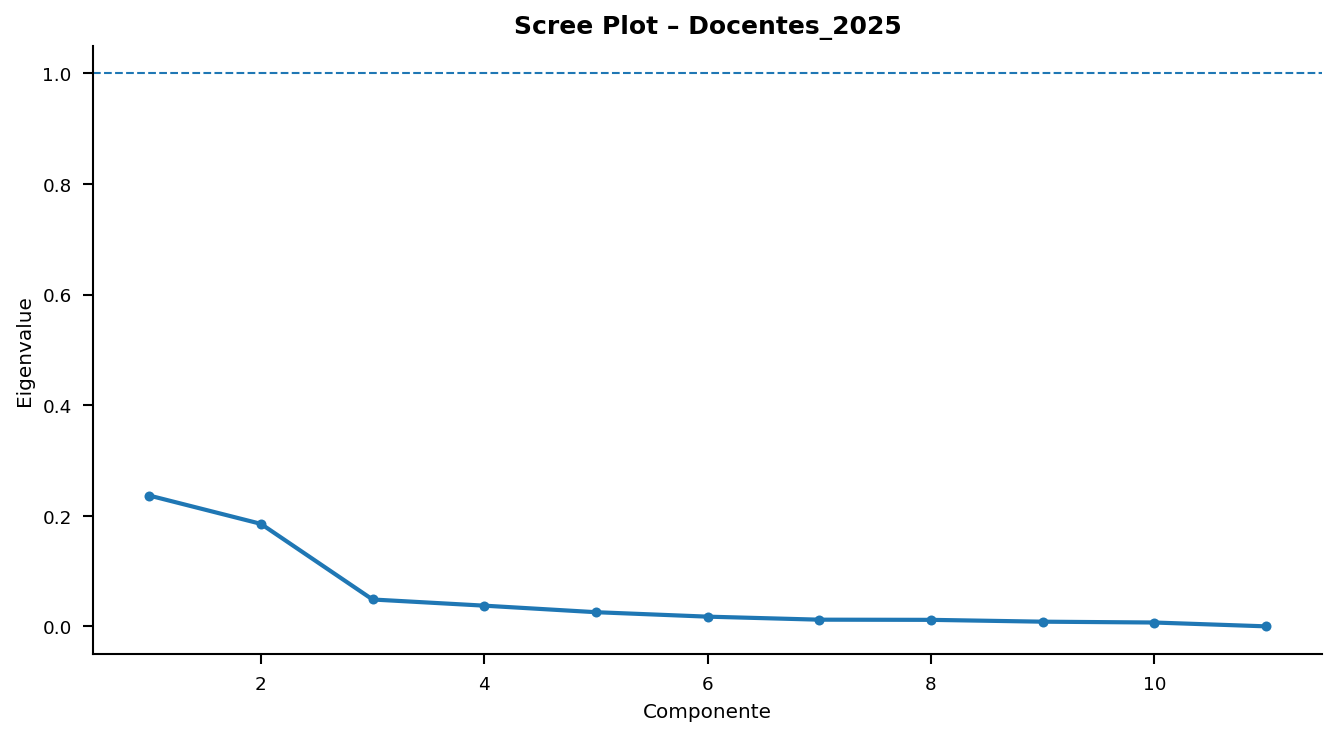

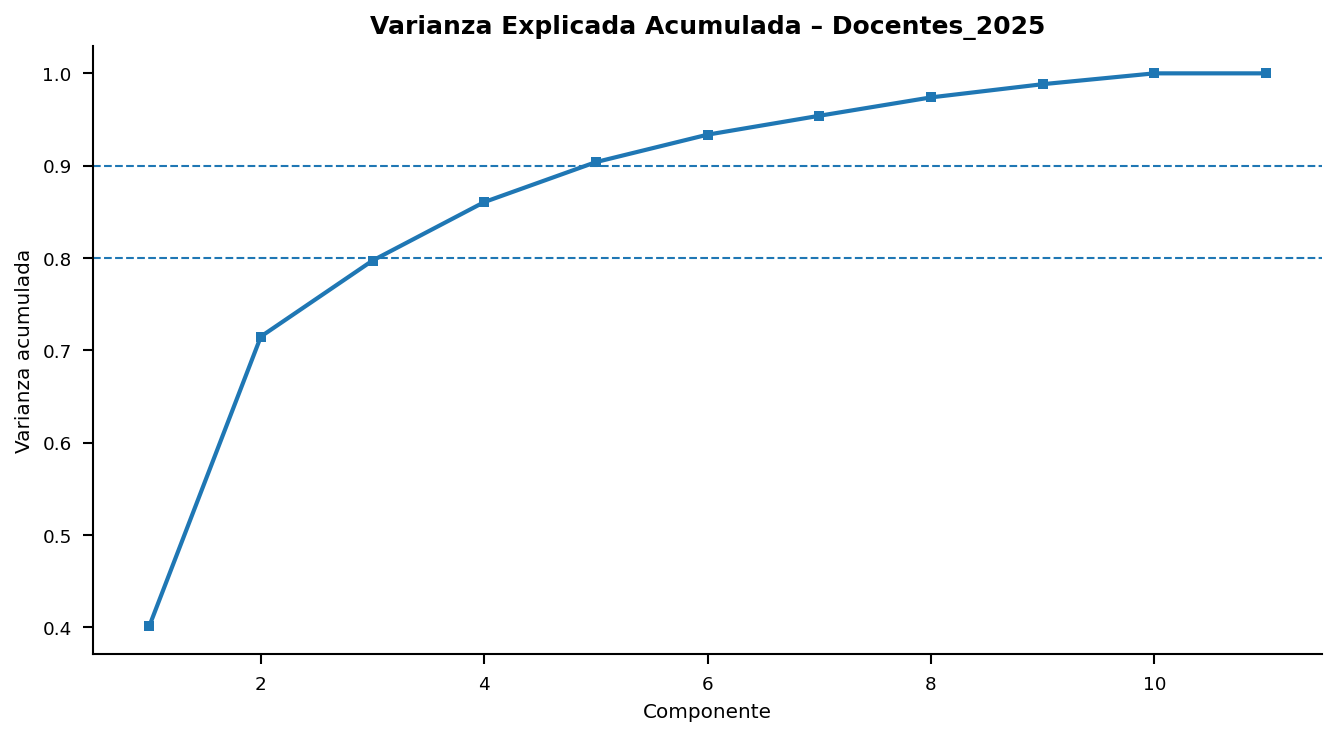

/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 3 is empty! self.labels_[self.medoid_indices_[3]] may not be labeled with its corresponding cluster (3).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarn

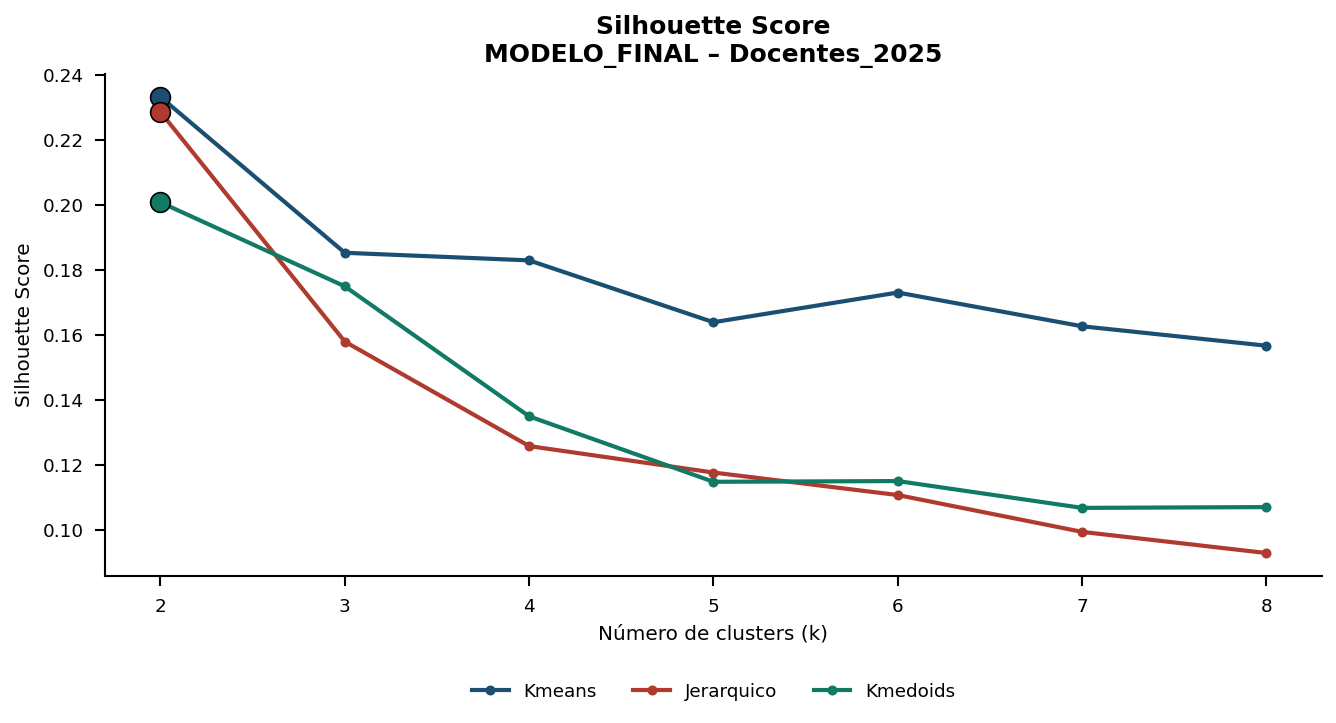

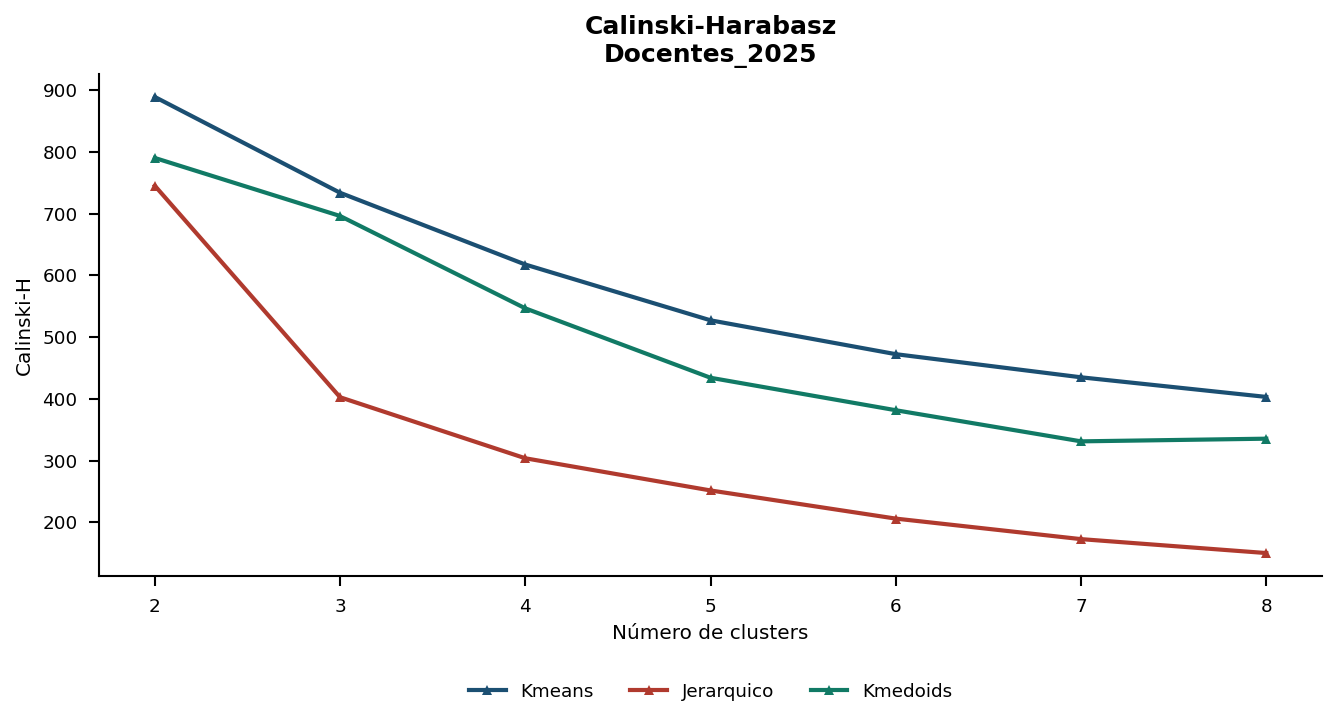

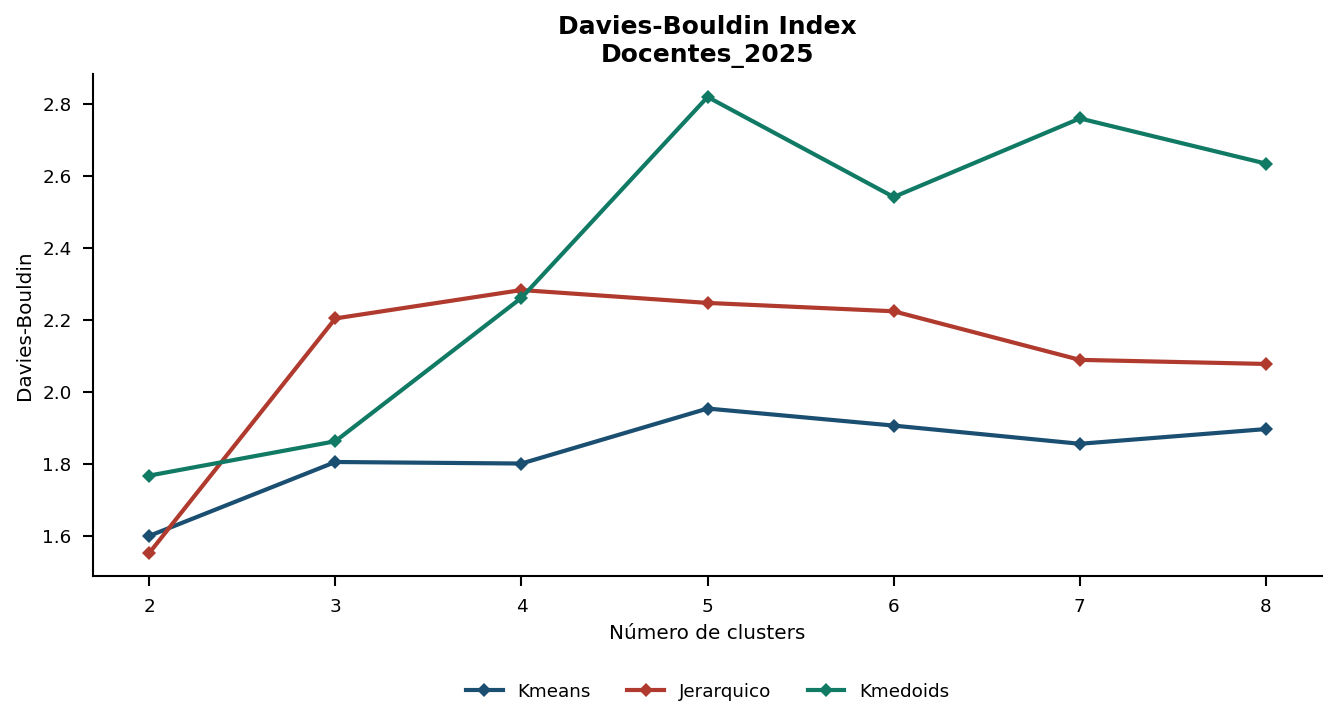


Método ganador: kmeans
k óptimo: 2


/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 3 is empty! self.labels_[self.medoid_indices_[3]] may not be labeled with its corresponding cluster (3).
  warnings.warn(



Archivos exportados correctamente.


,ID,tipo_doc,Documento,ApePaternoEvaluado,ApeMaternoEvaluado,NombreEvaluado,sex,fecha_nac,escala_final,IDLista,...,KMEANS_k2,KMEANS_k3,KMEANS_k4,JERARQUICO_k2,JERARQUICO_k3,JERARQUICO_k4,KMEDOIDS_k2,KMEDOIDS_k3,KMEDOIDS_k4,METODO_GANADOR_CLASIFICACION
1,193511.0,1.0,00011467,RIOS,CORDOVA,TONY,Masculino,1965-11-03,4.0,5495,...,1,1,1,0,1,1,0,0,0,1
5,178037.0,1.0,00018014,PORTOCARRERO,GOMEZ,ITALO,Masculino,1964-08-20,5.0,3433,...,1,1,1,0,1,1,0,0,0,1
7,91471.0,1.0,00021195,GARCIA,GOMEZ,VICTOR RAUL,Masculino,1962-04-07,6.0,5500,...,1,1,1,0,1,1,0,0,0,1
8,68128.0,1.0,00022362,DAVILA,ANDI,JAIME VIDAL,Masculino,1959-10-04,1.0,5546,...,0,0,2,1,0,0,0,2,3,0
9,213283.0,1.0,00022644,SANCHEZ,PEÑA,SIVILA,Femenino,1960-12-01,5.0,5501,...,1,1,1,0,1,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5772,67525.0,1.0,80050737,CUTIPA,CRUZ,EDWIN JULIO,Masculino,1974-10-25,4.0,4927,...,0,2,0,1,0,0,1,1,1,0
5774,164927.0,1.0,80086887,PALOMINO,CASTRO,PEDRO,Masculino,1979-05-03,6.0,3841,...,1,1,1,0,1,1,0,0,0,1
5775,65099.0,1.0,80100340,CRUZADO,BECERRA,JOSE WALTER,Masculino,1979-02-25,5.0,5275,...,0,2,2,1,0,0,1,1,1,0
5779,242512.0,1.0,80281242,VASQUEZ,PAISIG,FERNANDO,Masculino,1979-05-09,6.0,3202,...,0,2,0,1,0,0,1,1,1,0


In [8]:
feature_cols = [
    "D1S1",
    "D1S2",
    "D1S3",
    "D1S4",
    "D2S5",
    "D2S6",
    "D2S7",
    "D3S8",
    "D3S9",
    "D3S10",
    "D3S11"
]

# ==========================================================
# EJECUCIÓN DEL MODELO
# ==========================================================

ejecutar_clusterizacion(
    df=BD3,
    feature_cols=feature_cols,
    nombre_modelo="MODELO_FINAL",
    nombre_base="Docentes_2025"
)


ANÁLISIS COMPLETO: MODELO_FINAL_Director_confuncionDocente - Docentes_2025_Director_confuncionDocente

LOG PREPROCESAMIENTO:
- Imputación: mediana
- Escalado: StandardScaler
- Shape final matriz: (1716, 10)

ANÁLISIS PCA EXPLORATORIO FORMAL

Calculando matriz policórica...

Tabla PCA:
   Componente    Eigenvalue  Varianza_Explicada  Varianza_Acumulada
0           1  2.031261e-01        3.542143e-01            0.354214
1           2  1.819392e-01        3.172683e-01            0.671483
2           3  6.628713e-02        1.155925e-01            0.787075
3           4  3.522329e-02        6.142290e-02            0.848498
4           5  2.572882e-02        4.486630e-02            0.893364
5           6  1.955439e-02        3.409923e-02            0.927463
6           7  1.696830e-02        2.958958e-02            0.957053
7           8  1.324732e-02        2.310087e-02            0.980154
8           9  1.138083e-02        1.984606e-02            1.000000
9          10  1.647081e-33      

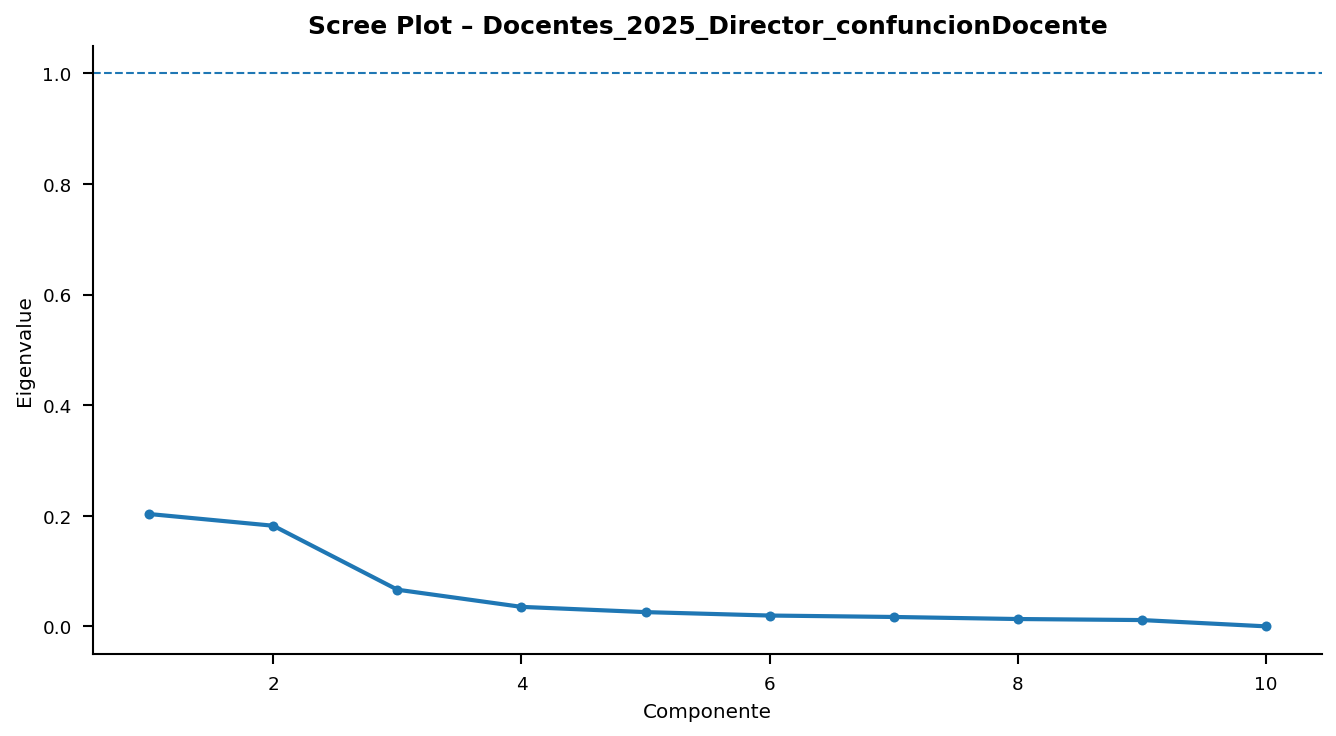

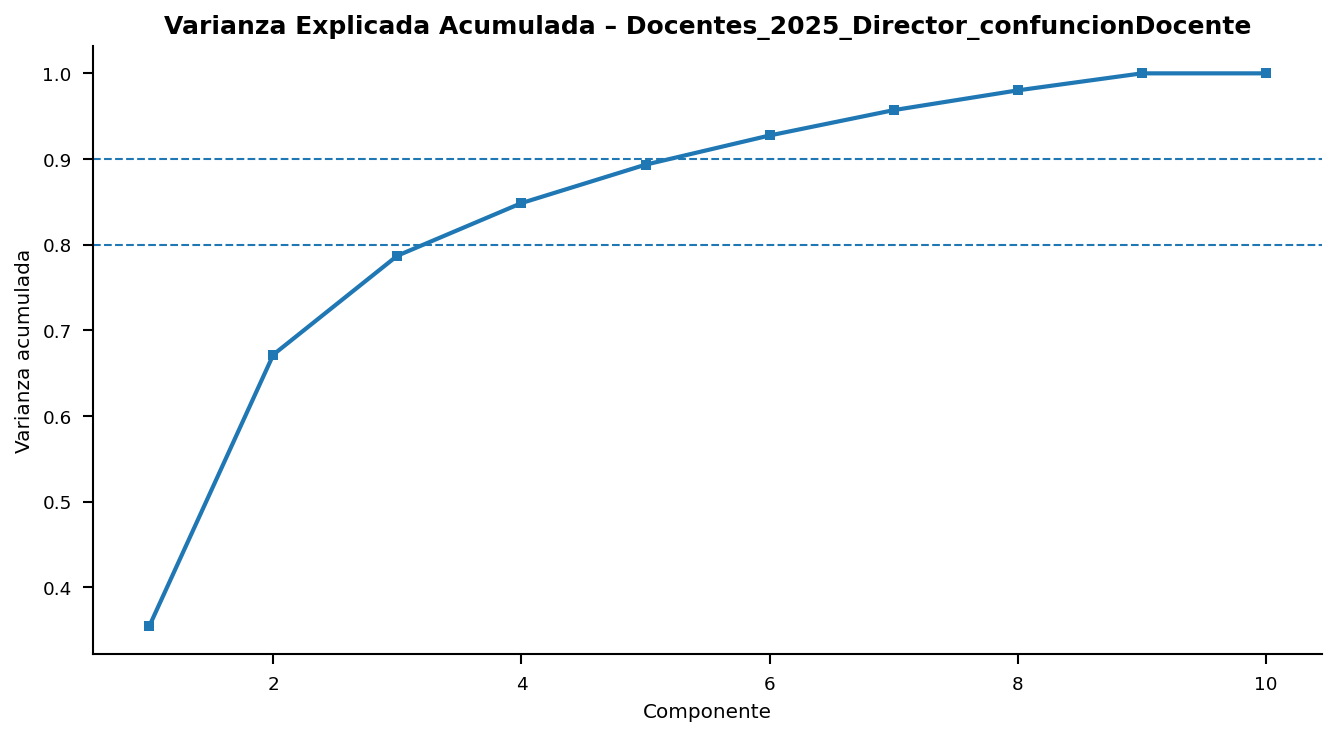

/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 3 is empty! self.labels_[self.medoid_indices_[3]] may not be labeled with its corresponding cluster (3).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 3 is empty! self.labels_[self.medoid_indices_[3]] may not be labeled with its corresponding cluster (3).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 3 is empty! self.labels_[self.medoid_indices_[3]] may not be labeled with its corresponding cluster (3).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 3 is empty! self.labels_[self.medoid_indices_[3]] may not be labeled with its corresponding cluster (3).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarn

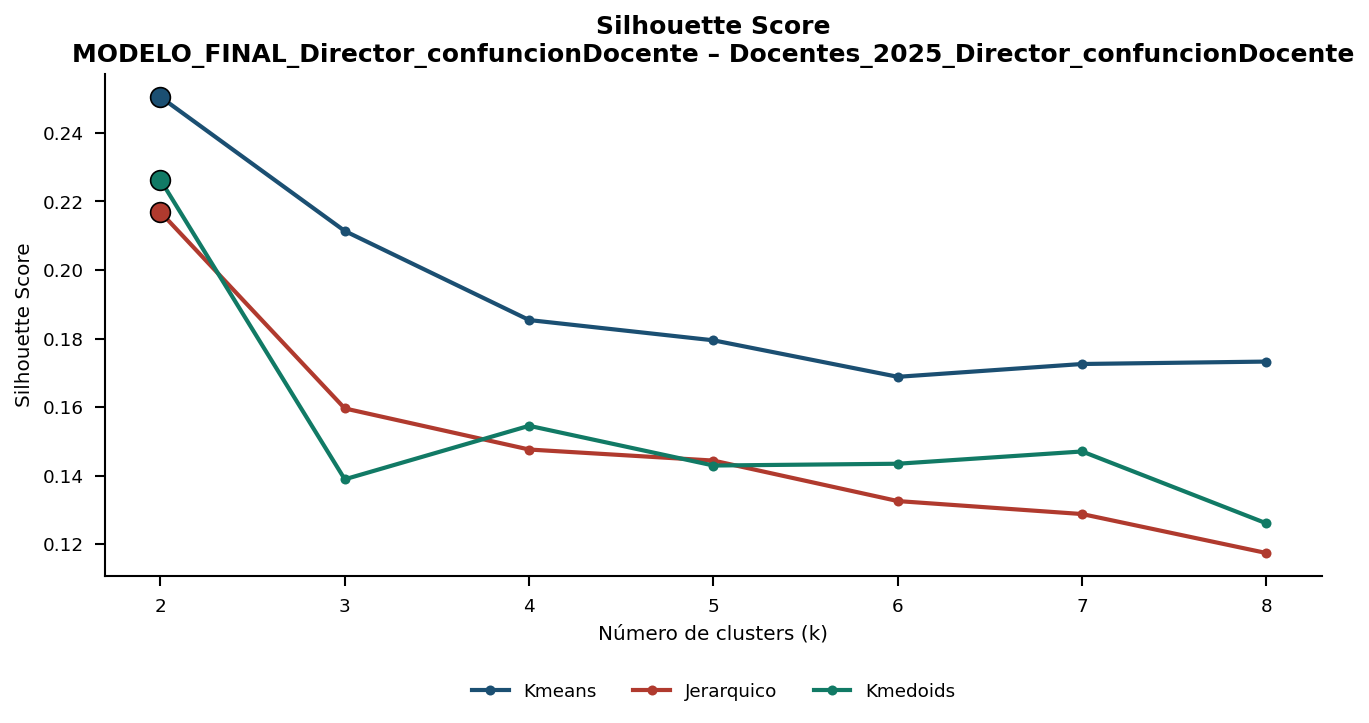

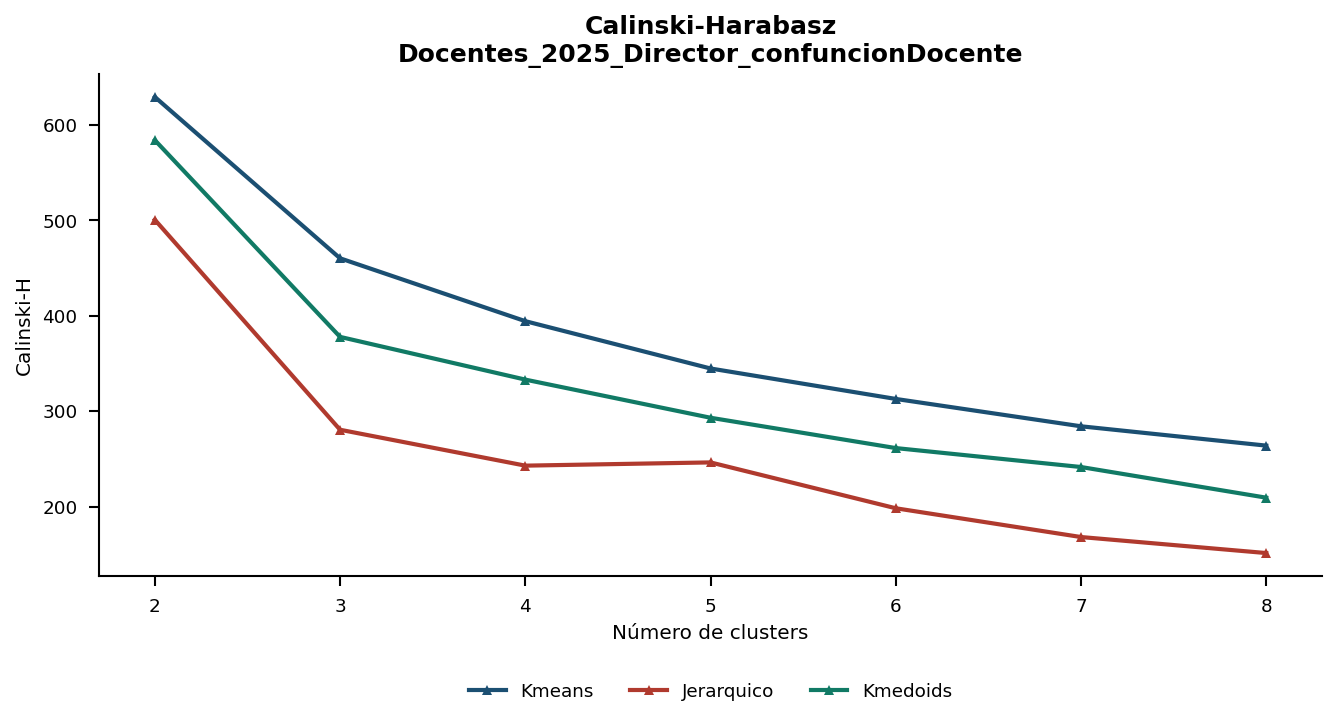

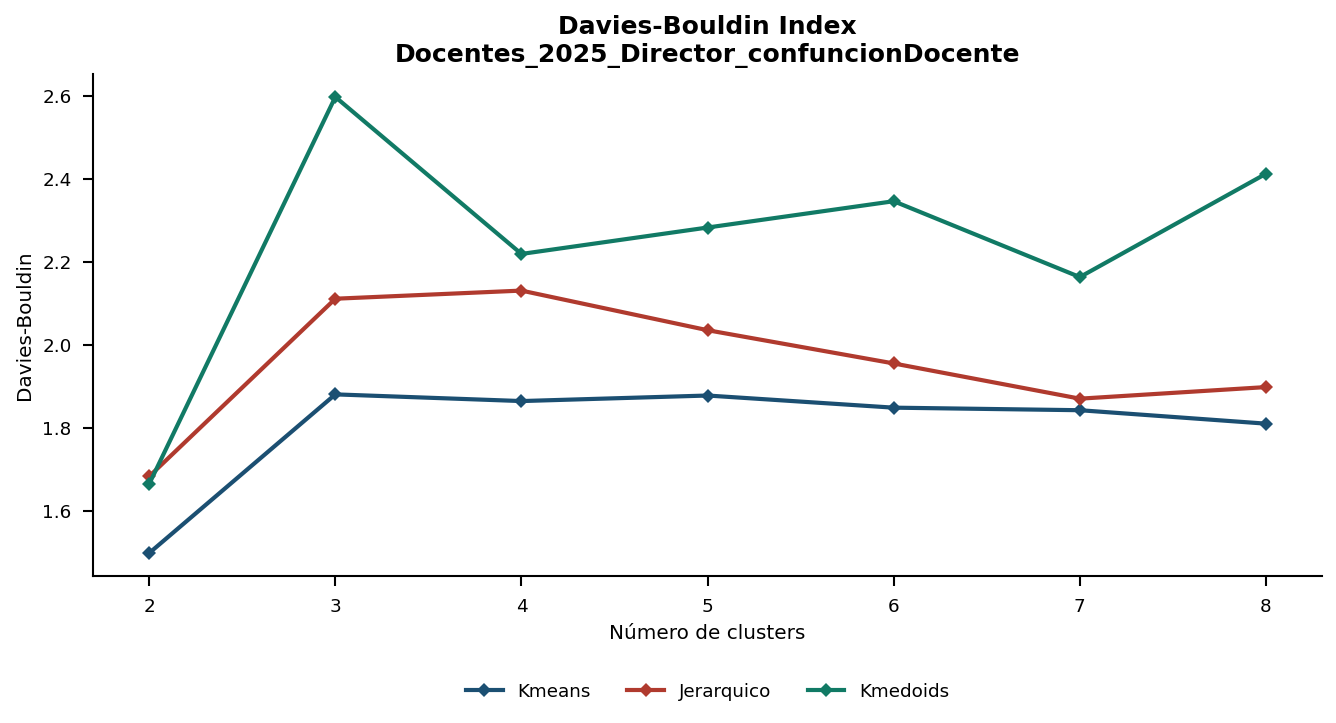


Método ganador: kmeans
k óptimo: 2

Archivos exportados correctamente.


/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 3 is empty! self.labels_[self.medoid_indices_[3]] may not be labeled with its corresponding cluster (3).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 3 is empty! self.labels_[self.medoid_indices_[3]] may not be labeled with its corresponding cluster (3).
  warnings.warn(


,ID,tipo_doc,Documento,ApePaternoEvaluado,ApeMaternoEvaluado,NombreEvaluado,sex,fecha_nac,escala_final,IDLista,...,KMEANS_k2,KMEANS_k3,KMEANS_k4,JERARQUICO_k2,JERARQUICO_k3,JERARQUICO_k4,KMEDOIDS_k2,KMEDOIDS_k4,KMEDOIDS_k7,METODO_GANADOR_CLASIFICACION
2,213588.0,1.0,00012733,SANCHEZ,ROJAS,CLAUDIA LUZ,Femenino,1962-05-14,4.0,5496,...,0,1,3,0,1,0,0,3,6,0
16,210864.0,1.0,00054857,SALVADOR,ALCALA,ORLANDO OSCAR,Masculino,1961-09-21,2.0,5506,...,1,0,1,1,0,3,1,1,4,1
27,88364.0,1.0,00091865,GALAN,GONZALES,ROBERT DEOMAR,Masculino,1971-02-22,2.0,2210,...,1,0,1,1,0,3,1,1,4,1
36,242528.0,1.0,00186861,VASQUEZ,PANDURO,ARNALDO,Masculino,1967-07-06,3.0,5523,...,1,0,1,1,0,3,1,1,4,1
40,172396.0,1.0,00202196,PEREZ,GONZAGA,MIRTHA CAROL,Femenino,1965-11-01,5.0,5454,...,1,0,1,1,0,3,1,1,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,75375.0,1.0,80138793,DUEÑAS,ROJAS,DAYER AUGUSTO,Masculino,1978-01-18,4.0,2042,...,0,1,3,0,1,0,0,2,2,0
5778,670.0,1.0,80205862,ACERO,RAMIREZ,JULIA PILAR,Femenino,1969-10-31,4.0,364,...,0,1,2,0,1,0,0,3,1,0
5780,235543.0,1.0,80351513,URBANO,NIÑO,ROGELIO ELIAS,Masculino,1976-12-19,6.0,2168,...,0,1,2,0,1,0,0,3,6,0
5782,170936.0,1.0,80416941,PEÑALOZA,HUANCA,ALEXANDER RUSO,Masculino,1976-03-07,5.0,5643,...,1,0,2,0,1,0,1,3,1,1


In [9]:
feature_cols = [
    "D1S1",
#    "D1S2",
    "D1S3",
    "D1S4",
    "D2S5",
    "D2S6",
    "D2S7",
    "D3S8",
    "D3S9",
    "D3S10",
    "D3S11"
]

# ==========================================================
# EJECUCIÓN DEL MODELO
# ==========================================================

ejecutar_clusterizacion(
    df=BD4,
    feature_cols=feature_cols,
    nombre_modelo="MODELO_FINAL_Director_confuncionDocente",
    nombre_base="Docentes_2025_Director_confuncionDocente"
)


ANÁLISIS COMPLETO: MODELO_FINAL_Subdirector_sinfuncionDocente - Docentes_2025_Subdirector_sinfuncionDocente

LOG PREPROCESAMIENTO:
- Imputación: mediana
- Escalado: StandardScaler
- Shape final matriz: (965, 9)

ANÁLISIS PCA EXPLORATORIO FORMAL

Calculando matriz policórica...

Tabla PCA:
   Componente    Eigenvalue  Varianza_Explicada  Varianza_Acumulada
0           1  3.945225e-01        5.849562e-01            0.584956
1           2  1.389961e-01        2.060888e-01            0.791045
2           3  6.198290e-02        9.190168e-02            0.882947
3           4  2.875425e-02        4.263376e-02            0.925580
4           5  1.865235e-02        2.765573e-02            0.953236
5           6  1.415250e-02        2.098383e-02            0.974220
6           7  1.121947e-02        1.663504e-02            0.990855
7           8  6.167800e-03        9.144962e-03            1.000000
8           9  6.751849e-34        1.001093e-33            1.000000


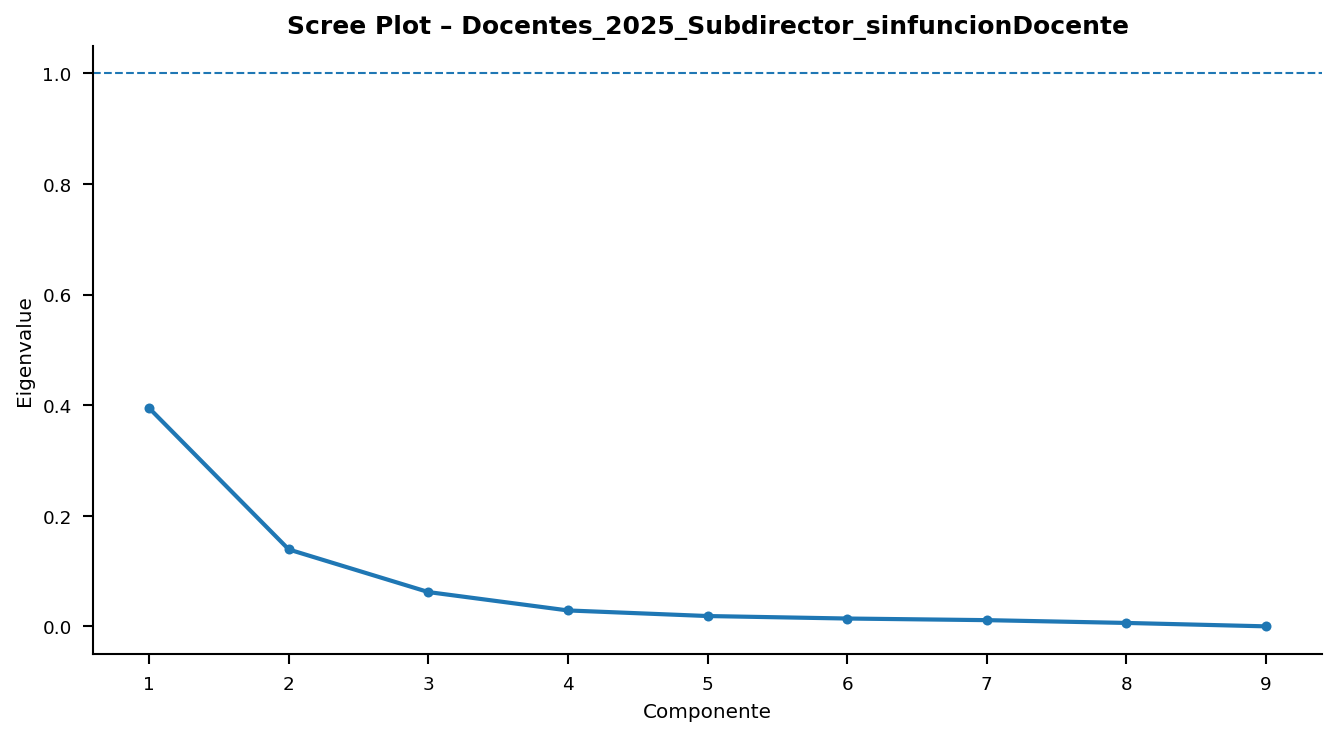

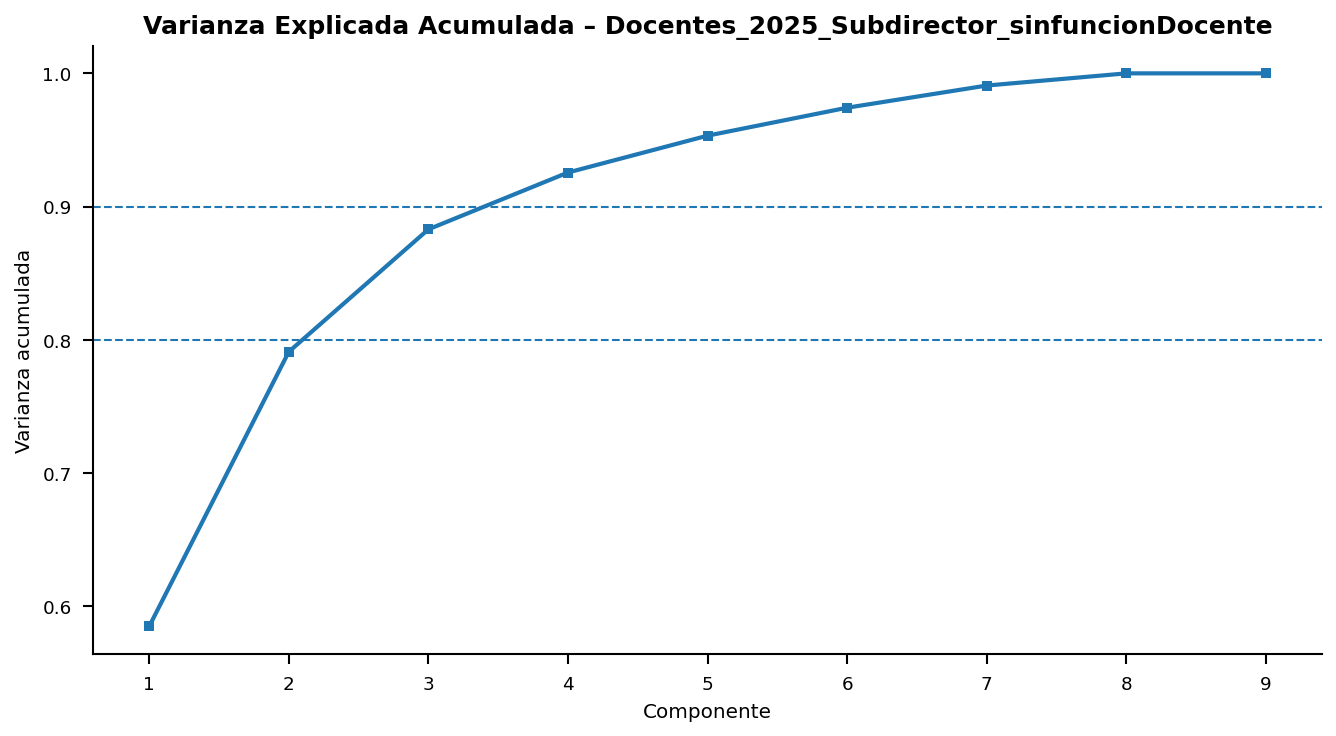

/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarn

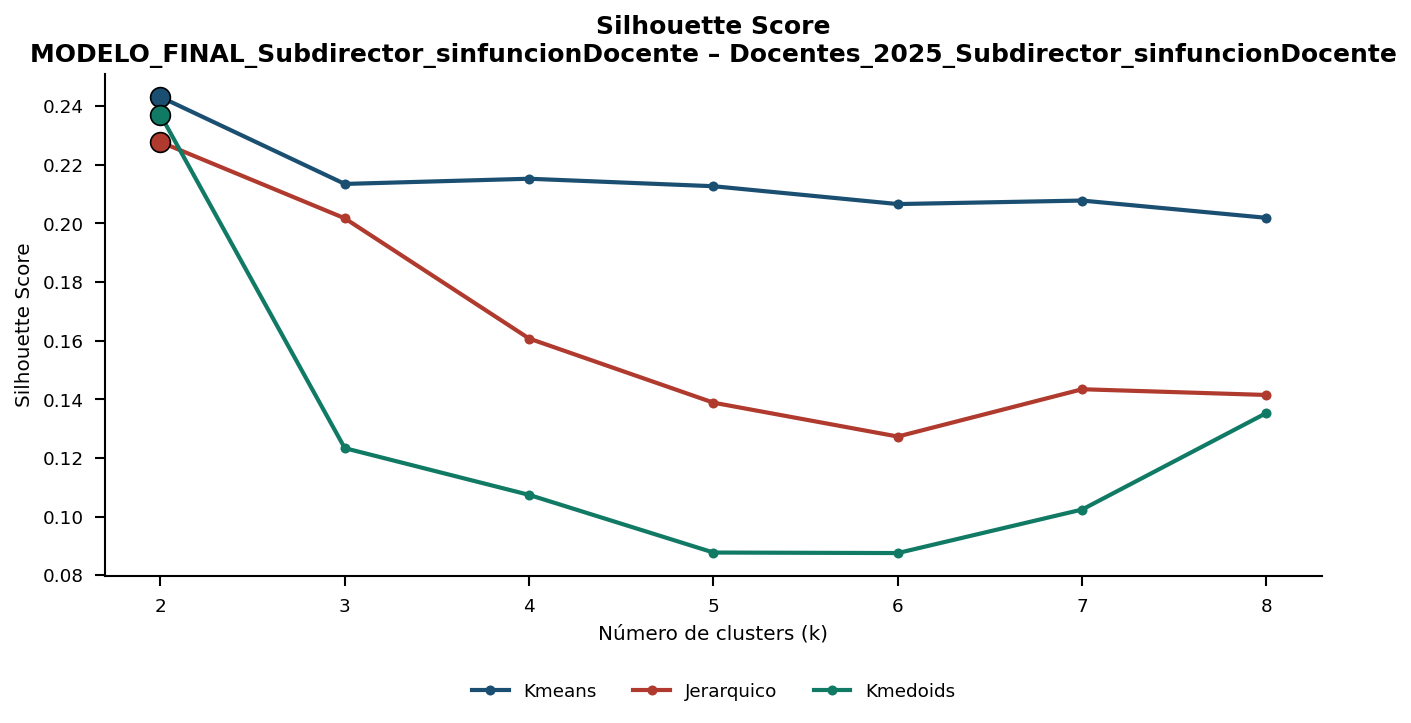

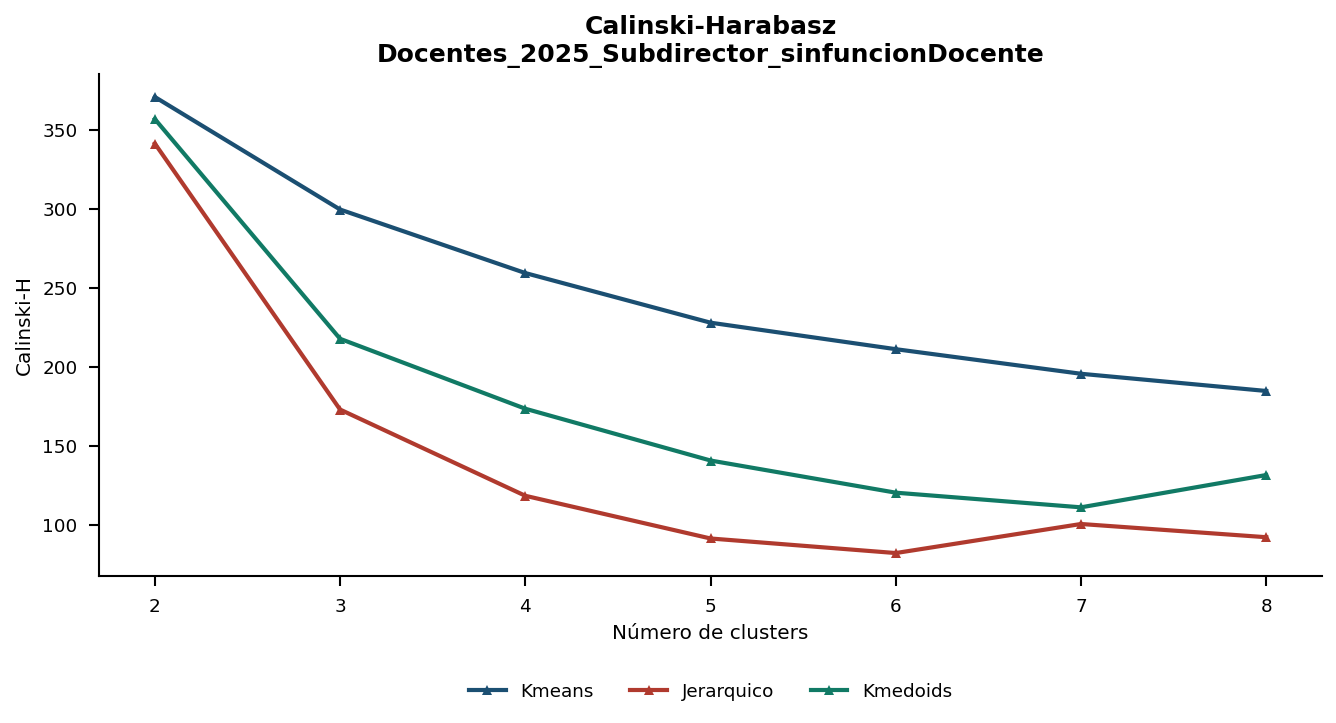

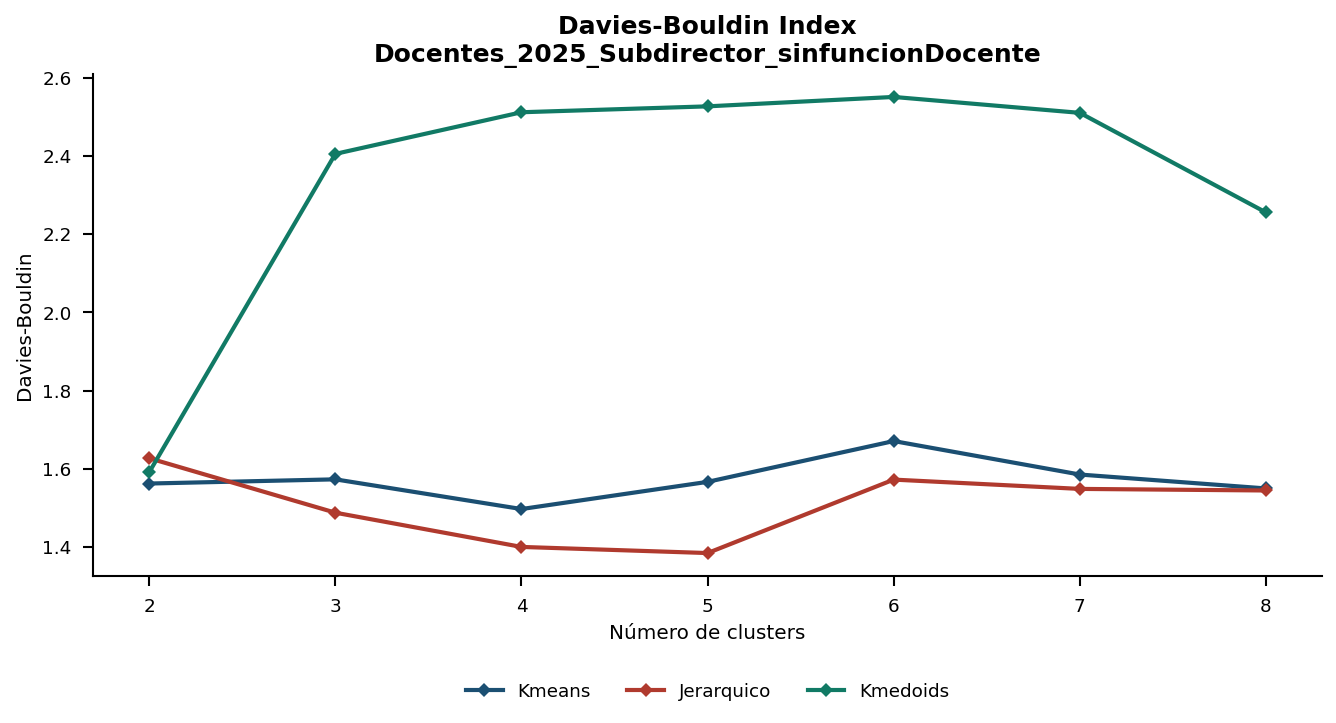


Método ganador: kmeans
k óptimo: 2

Archivos exportados correctamente.


/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 5 is empty! self.labels_[self.medoid_indices_[5]] may not be labeled with its corresponding cluster (5).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(


,ID,tipo_doc,Documento,ApePaternoEvaluado,ApeMaternoEvaluado,NombreEvaluado,sex,fecha_nac,escala_final,IDLista,...,KMEANS_k2,KMEANS_k4,KMEANS_k3,JERARQUICO_k2,JERARQUICO_k3,JERARQUICO_k4,KMEDOIDS_k2,KMEDOIDS_k8,KMEDOIDS_k3,METODO_GANADOR_CLASIFICACION
17,100342.0,1.0,00062271,GUEVARA,TUESTA,CLOTILDE DORIS,Femenino,1960-07-14,3.0,5507,...,0,3,0,1,1,0,0,6,0,0
18,96818.0,1.0,00069958,GONZALES,PEREZ,MERY,Femenino,1964-02-27,3.0,5508,...,1,0,2,0,0,1,1,7,2,1
32,73160.0,1.0,00118438,DIAZ,LOZANO,TANIA LIBERTAD,Femenino,1974-08-18,5.0,5520,...,0,3,0,1,1,0,0,5,0,0
33,20276.0,1.0,00120690,AYACHI,PILCO,TRINIDAD,Masculino,1966-07-07,1.0,5521,...,1,2,1,0,0,1,1,2,2,1
34,140267.0,1.0,00124449,MEJICO,CABALLERO,LUDY ROSMERY,Femenino,1977-08-07,5.0,5522,...,0,3,0,1,1,0,0,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5655,58479.0,1.0,33734386,CONCHE,HUAMAN,MARLITH,Femenino,1973-04-09,4.0,3811,...,0,3,0,1,1,0,0,0,0,0
5688,56863.0,1.0,33954660,CISNEROS,GRANDEZ,EDGAR,Masculino,1973-08-22,5.0,3580,...,0,3,0,1,1,0,0,3,0,0
5695,82204.0,1.0,40034175,FERNANDEZ,BRAVO,ANTERO CRISTIAN,Masculino,1978-09-08,6.0,3057,...,0,3,0,1,1,0,0,0,0,0
5728,131729.0,1.0,40294398,MAMANI,AQUISE,JORGE WELLINGTON,Masculino,1979-07-02,3.0,5184,...,1,0,2,0,0,1,1,7,1,1


In [10]:
feature_cols = [
    "D1S1",
    "D1S2",
    "D1S3",
    "D1S4",
    "D2S5",
    "D2S6",
    "D2S7",
    "D3S8",
    "D3S9",
#    "D3S10",
#    "D3S11"
]

# ==========================================================
# EJECUCIÓN DEL MODELO
# ==========================================================

ejecutar_clusterizacion(
    df=BD5,
    feature_cols=feature_cols,
    nombre_modelo="MODELO_FINAL_Subdirector_sinfuncionDocente",
    nombre_base="Docentes_2025_Subdirector_sinfuncionDocente"
)

# Descriptivos de los perfiles

### Director sin funcion docente

In [55]:
B_G1 = pd.read_csv("/Users/cristianmolina/Desktop/Proyectos MINEDU 2026 - Github/Investigacion_EDDIR_IE_2024/outputs/Docentes_2025_clusterizada_MODELO_FINAL.csv", dtype = {"Documento":str}, sep=",")

In [56]:
## EDAD
# Asegurar formato fecha
B_G1["fecha_nac"] = pd.to_datetime(B_G1["fecha_nac"])
# Fecha de corte
fecha_corte = pd.to_datetime("2024-05-28")
# Variable edad (cálculo exacto)
B_G1["edad"] = (fecha_corte.year - B_G1["fecha_nac"].dt.year - ((fecha_corte.month < B_G1["fecha_nac"].dt.month) | ((fecha_corte.month == B_G1["fecha_nac"].dt.month) & (fecha_corte.day < B_G1["fecha_nac"].dt.day))))

## Ley de procedencia
B_G1 = pd.merge(B_G1, BD_Maestra[["DNI", "LEY_PROCEDE_max2"]], left_on="Documento", right_on="DNI", how="inner")

## Nexus nombrados jul 24
B_G1 = pd.merge(B_G1, Nexus_nomb_Jul24_u[["ubicod", "DNI"]], left_on="Documento", right_on="DNI", how="inner")

## IDH distrital
B_G1 = pd.merge(B_G1, IDH_distrital[["UBIGEO", "IDH", "Ingreso real per cápita del hogar"]], left_on="ubicod", right_on="UBIGEO", how="left")

## Habilitados
B_G1 = pd.merge(
    B_G1,
    Habilitados_v2.drop_duplicates(subset=["DNI"]),
    left_on="Documento",
    right_on="DNI",
    how="left"
)

## Codigos modulares de los niveles rural 1, rural 2, rural 3 y no rural
B_G1 = pd.merge(B_G1, codmods_r1_por_dni, left_on="Documento", right_on="DNI", how="left",suffixes=("", "_R1"))
B_G1 = pd.merge(B_G1, codmods_r2_por_dni, left_on="Documento", right_on="DNI", how="left",suffixes=("", "_R2"))
B_G1 = pd.merge(B_G1, codmods_r3_por_dni, left_on="Documento", right_on="DNI", how="left",suffixes=("", "_R3"))

## Nexus contratados julio 2024
B_G1 = pd.merge(B_G1, Contratados_unicos_codmodce, left_on="COD_MOD", right_on="codmodce", how = "left", suffixes=("", "_codmodce"))

## Docentes unicos cod mod ce
B_G1 = pd.merge(B_G1, Docentes_unicos_codmodce, left_on="COD_MOD", right_on="codmodce", how = "left", suffixes=("", "_codmodce_docentes_total"))

## Codigo moduilares de selva baja (atencion)
B_G1 = pd.merge(B_G1, Cod_mods_selva_baja_bd, left_on="Documento", right_on="DocumentoIdentidadEvaluado", how = "left", suffixes=("", "_selva"))

## Tiempo de ugel
B_G1 = pd.merge(B_G1, Accesibilidad_DNI, left_on="Documento", right_on="DocumentoIdentidadEvaluado", how="left", suffixes=("", "_accesibilidad"))

## Alumnos por DNI
B_G1 = pd.merge(B_G1, Alumnas_DNI, left_on="Documento", right_on="DNI", how="left", suffixes=('', '_alumnos_x_documentos'))

## Equipo directivo
B_G1 = pd.merge(B_G1, Equipo_directivo, left_on="COD_MOD", right_on="codmodce", how = "left", suffixes=("", "_codmodce_equipo_total"))

##Subdirectores por codmodce
B_G1 = pd.merge(B_G1, Subdirectores_julio2024, left_on="COD_MOD", right_on="codmodce", how = "left", suffixes=("", "_codmodce_subdirectores"))

## Reconocimientos 2024
B_G1 = pd.merge(B_G1, Reconocimientos_F, left_on="Documento", right_on="DNI", how="left", suffixes=("", "_reconocimientos2024"))

## Formacion
B_G1 = pd.merge(B_G1, Formacion[["Documento",
           "Gestión de la dimensión administrativa en la IE 2024-Activo en el curso",
           "Migración y Escuela 2024-Activo en el curso",
           "Caos y Complejidad 2024-Activo en el curso"
           ]], left_on="Documento", right_on="Documento", how="left")

## MPE_IE
B_G1 = pd.merge(B_G1, MPE_IE_2, left_on="COD_MOD", right_on="COD_MODULAR_FIN", how="left")
B_G1 = pd.merge(B_G1, MPE_SESION_3, left_on="COD_MOD", right_on="COD_MODULAR", how="left")

In [58]:
B_G1

,ID,tipo_doc,Documento,ApePaternoEvaluado,ApeMaternoEvaluado,NombreEvaluado,sex,fecha_nac,escala_final,IDLista,...,GESTION_4,COD_MODULAR,IND_1,IND_2,IND_3,IND_4,IND_5,IND_6,IND_7,IND_8
0,193511.0,1.0,00011467,RIOS,CORDOVA,TONY,Masculino,1965-11-03,4.0,5495,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,178037.0,1.0,00018014,PORTOCARRERO,GOMEZ,ITALO,Masculino,1964-08-20,5.0,3433,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,91471.0,1.0,00021195,GARCIA,GOMEZ,VICTOR RAUL,Masculino,1962-04-07,6.0,5500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,68128.0,1.0,00022362,DAVILA,ANDI,JAIME VIDAL,Masculino,1959-10-04,1.0,5546,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,213283.0,1.0,00022644,SANCHEZ,PEÑA,SIVILA,Femenino,1960-12-01,5.0,5501,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2567,67525.0,1.0,80050737,CUTIPA,CRUZ,EDWIN JULIO,Masculino,1974-10-25,4.0,4927,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2568,164927.0,1.0,80086887,PALOMINO,CASTRO,PEDRO,Masculino,1979-05-03,6.0,3841,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2569,65099.0,1.0,80100340,CRUZADO,BECERRA,JOSE WALTER,Masculino,1979-02-25,5.0,5275,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2570,242512.0,1.0,80281242,VASQUEZ,PAISIG,FERNANDO,Masculino,1979-05-09,6.0,3202,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd
import numpy as np

grupos = [
    "KMEANS_k3", "KMEANS_k4",
    "JERARQUICO_k3", "JERARQUICO_k4",
    "KMEDOIDS_k3", "KMEDOIDS_k4"
]

# =========================================================
# CONFIGURACIÓN GENERAL
# =========================================================

# Variables numéricas
vars_num = [
    "D1S1", "D1S2", "D1S3", "D1S4",
    "D2S5", "D2S6", "D2S7",
    "D3S8", "D3S9", "D3S10", "D3S11",
    "edad", "IDH", "Ingreso real per cápita del hogar",
    "TIEMPO_UGEL",
    "talumno_alumnos_x_documentos",
    "DNI_codmodce_subdirectores",
    "CLIMA_1", "CLIMA_2",
    "GESTION_1", "GESTION_2", "GESTION_3", "GESTION_4",
    "IND_1", "IND_2", "IND_3", "IND_4",
    "IND_5", "IND_6", "IND_7", "IND_8"
]

# Variables categóricas
vars_cat = ["sex", "LEY_PROCEDE_max2", "TipodeRuralidad"]

# Variables de cursos (solo "Sí")
cols_cursos = [
    "Gestión de la dimensión administrativa en la IE 2024-Activo en el curso",
    "Migración y Escuela 2024-Activo en el curso",
    "Caos y Complejidad 2024-Activo en el curso"
]

orden_filas = [
    "D1S1",
    "D1S2",
    "D1S3",
    "D1S4",
    "D2S5",
    "D2S6",
    "D2S7",
    "D3S8",
    "D3S9",
    "D3S10",
    "D3S11",
    "Total de directivos",
    "sex_Femenino",
    "[Fila agregada, el porcentaje se obtuvo dividiendo el número de mujeres directivos entre el N total]",
    "edad",
    "CLIMA_1",
    "CLIMA_2",
    "GESTION_1",
    "GESTION_2",
    "GESTION_3",
    "GESTION_4",
    "IND_1",
    "IND_2",
    "IND_3",
    "IND_4",
    "IND_5",
    "IND_6",
    "IND_7",
    "IND_8",
    "LEY_PROCEDE_max2_CPM",
    "LEY_PROCEDE_max2_PROF",
    "talumno_alumnos_x_documentos",
    "DNI_codmodce",
    "DNI_codmodce_subdirectores",
    "Reconocimientos_2024",
    "Gestión de la dimensión administrativa en la IE 2024-Activo en el curso",
    "Migración y Escuela 2024-Activo en el curso",
    "Caos y Complejidad 2024-Activo en el curso",
    "IDH",
    "Ingreso real per cápita del hogar",
    "TIEMPO_UGEL",
    "n_codmods_R1",
    "n_codmods_R2",
    "n_codmods_R3",
    "CodModularIEAgregada_1.0",
    "CodModularIEAgregada_2.0",
    "CodModularIEAgregada_3.0",
    "TipodeRuralidad_No Rural",
    "TipodeRuralidad_Rural 1",
    "TipodeRuralidad_Rural 2",
    "TipodeRuralidad_Rural 3"
]

indicadores = {
    "D1S1": "S1 Planificación curricular",
    "D1S2": "S2 Monitoreo de la práctica\npedagógica en el aula",
    "D1S3": "S3 Fortalecimiento de las\ncompetencias docentes",
    "D1S4": "S4 Seguimiento al progreso\nde los aprendizajes",
    "D2S5": "S5 Participación de la\ncomunidad educativa para\nel bienestar escolar",
    "D2S6": "S6 Relaciones\ninterpersonales en la\ninstitución educativa",
    "D2S7": "S7 Gestión de la\nconvivencia escolar",
    "D3S8": "S8 Seguridad y salubridad",
    "D3S9": "S9 Gestión de los recursos\neducativos",
    "D3S10": "S10 Matrícula y\npreservación del derecho a\nla educación",
    "D3S11": "S11 Gestión transparente\nde los recursos financieros",
    "N": "Total de directivos",
    "sex_Femenino": "Número de directivos que son mujeres",
    "[Fila agregada, el porcentaje se obtuvo dividiendo el número de mujeres directivos entre el N total]": "% directivos que son mujeres",
    "edad": "Edad promedio en el año en que fue evaluado",
    "CLIMA_1": "Promedio alcanzado en normas de convivencia de la IE",
    "CLIMA_2": "Promedio alcanzado en relaciones profesionales",
    "GESTION_1": "Promedio alcanzado en monitoreo de la práctica pedagógica",
    "GESTION_2": "Promedio alcanzado en planificación institucional",
    "GESTION_3": "Promedio alcanzado en aprovechamiento del tiempo",
    "GESTION_4": "Promedio alcanzado en trabajo colaborativo",
    "IND_1": "Promedio alcanzado en estructura",
    "IND_2": "Promedio alcanzado en maximización",
    "IND_3": "Promedio alcanzado en pensamiento crítico",
    "IND_4": "Promedio alcanzado en involucramiento",
    "IND_5": "Promedio alcanzado en monitoreo y retroalimentación",
    "IND_6": "Promedio alcanzado en retroalimentación escrita",
    "IND_7": "Promedio alcanzado en relaciones durante la sesión de aprendizaje",
    "IND_8": "Promedio alcanzado en el manejo del comportamiento",
    "LEY_PROCEDE_max2_CPM": "Número de docentes nombrados en la CPM",
    "LEY_PROCEDE_max2_PROF": "Número de docentes nombrados por la ley del PROF",
    "talumno_alumnos_x_documentos": "Cantidad promedio de estudiantes en el codmod a cargo del directivo",
    "DNI_codmodce": "Cantidad promedio de docentes de la IE.",
    "DNI_codmodce_subdirectores": "Cantidad promedio de subdirectores designados (por IE)",
    "Reconocimientos_2024": "Número de docentes reconocidos en el 2024",
    "Gestión de la dimensión administrativa en la IE 2024-Activo en el curso": "Número de docentes activos en el curso de gestión de la dimensión administrativa en la IE 2024",
    "Migración y Escuela 2024-Activo en el curso": "Número de docentes activos en el curso de migración y escuela",
    "Caos y Complejidad 2024-Activo en el curso": "Número de docentes activos en el curso de caos y complejidad",
    "IDH": "Promedio de IDH a nivel distrital",
    "Ingreso real per cápita del hogar": "Ingreso promedio real per cápita del hogar a nivel distrital",
    "TIEMPO_UGEL": "Número de horas lejos de la UGEL más próxima",
    "n_codmods_R1": "Número de códigos modulares atendidos por los directivos pertenecientes a una IE de tipo Rural 1",
    "n_codmods_R2": "Número de códigos modulares atendidos por los directivos pertenecientes a una IE de tipo Rural 2",
    "n_codmods_R3": "Número de códigos modulares atendidos por los directivos pertenecientes a una IE de tipo Rural 3",
    "CodModularIEAgregada_1.0": "Número de docentes que atienden una IE ubicada en zona baja de selva",
    "CodModularIEAgregada_2.0": "Número de docentes que atienden dos IE ubicada en zona baja de selva",
    "CodModularIEAgregada_3.0": "Número de docentes que atienden tres IE ubicada en zona baja de selva",
    "TipodeRuralidad_No Rural": "Número de docentes nombrados en plaza de tipo No rural",
    "TipodeRuralidad_Rural 1": "Número de docentes nombrados en plaza de tipo Rural 1",
    "TipodeRuralidad_Rural 2": "Número de docentes nombrados en plaza de tipo Rural 2",
    "TipodeRuralidad_Rural 3": "Número de docentes nombrados en plaza de tipo Rural 3",
}

filas_enteras = {
    "N",
    "sex_Femenino",
    "edad",
    "LEY_PROCEDE_max2_CPM",
    "LEY_PROCEDE_max2_PROF",
    "DNI_codmodce",
    "DNI_codmodce_subdirectores",
    "Reconocimientos_2024",
    "Gestión de la dimensión administrativa en la IE 2024-Activo en el curso",
    "Migración y Escuela 2024-Activo en el curso",
    "Caos y Complejidad 2024-Activo en el curso",
    "n_codmods_R1",
    "n_codmods_R2",
    "n_codmods_R3",
    "CodModularIEAgregada_1.0",
    "CodModularIEAgregada_2.0",
    "CodModularIEAgregada_3.0",
    "TipodeRuralidad_No Rural",
    "TipodeRuralidad_Rural 1",
    "TipodeRuralidad_Rural 2",
    "TipodeRuralidad_Rural 3",
}

fila_porcentaje = "[Fila agregada, el porcentaje se obtuvo dividiendo el número de mujeres directivos entre el N total]"

def formatear_valor(variable, valor):
    if pd.isna(valor):
        return ""
    if variable == fila_porcentaje:
        return f"{valor:.1f}%"
    if variable in filas_enteras:
        return f"{valor:.0f}"
    return f"{valor:.2f}"

with pd.ExcelWriter("tablas_formateadas_clusters.xlsx", engine="openpyxl") as writer:
    for grupo in grupos:
        tablas = []

        # 1) Medias por cluster
        tabla_num = B_G1.groupby(grupo)[vars_num].mean().T
        tabla_num.index.name = "variable"
        tablas.append(tabla_num)

        # 2) Tamaño del cluster (N)
        tabla_n = (
            B_G1.groupby(grupo)
            .size()
            .to_frame(name="N")
            .T
        )
        tabla_n.index = ["N"]
        tabla_n.index.name = "variable"
        tablas.append(tabla_n)

        # 3) Sumas de codmods por cluster
        tabla_r = B_G1.groupby(grupo)[
            ["n_codmods_R1", "n_codmods_R2", "n_codmods_R3"]
        ].sum()
        tabla_r["n_codmods_total"] = tabla_r.sum(axis=1)
        tabla_r = tabla_r.T
        tabla_r.index.name = "variable"
        tablas.append(tabla_r)

        # 4) Suma de DNI_codmodce por cluster
        tabla_codmodce = (
            B_G1.groupby(grupo)["DNI_codmodce"]
            .sum()
            .to_frame()
            .T
        )
        tabla_codmodce.index = ["DNI_codmodce"]
        tabla_codmodce.index.name = "variable"
        tablas.append(tabla_codmodce)

        # 5) Suma de DNI_codmodce_docentes_total por cluster
        tabla_docentes = (
            B_G1.groupby(grupo)["DNI_codmodce_docentes_total"]
            .sum()
            .to_frame()
            .T
        )
        tabla_docentes.index = ["DNI_codmodce_docentes_total"]
        tabla_docentes.index.name = "variable"
        tablas.append(tabla_docentes)

        # 6) Suma de Reconocimientos_2024
        tabla_reconocimientos = (
            B_G1.groupby(grupo)["Reconocimientos_2024"]
            .sum()
            .to_frame()
            .T
        )
        tabla_reconocimientos.index = ["Reconocimientos_2024"]
        tabla_reconocimientos.index.name = "variable"
        tablas.append(tabla_reconocimientos)

        # 7) Participación en cursos (solo "Sí")
        df_cursos = B_G1[cols_cursos].apply(lambda x: x.map({"Sí": 1, "No": 0}))
        tabla_cursos = (
            df_cursos.groupby(B_G1[grupo])
            .sum()
            .T
        )
        tabla_cursos.index.name = "variable"
        tablas.append(tabla_cursos)

        # 8) Crosstab de CodModularIEAgregada
        tabla_codmod = pd.crosstab(
            B_G1["CodModularIEAgregada"],
            B_G1[grupo],
            margins=True
        )
        tabla_codmod.index = [f"CodModularIEAgregada_{i}" for i in tabla_codmod.index]
        tabla_codmod.index.name = "variable"
        tablas.append(tabla_codmod)

        # 9) Frecuencias categóricas
        for var in vars_cat:
            tabla_cat = pd.crosstab(B_G1[var], B_G1[grupo], dropna=False)
            tabla_cat.index = [f"{var}_{i}" for i in tabla_cat.index]
            tabla_cat.index.name = "variable"
            tablas.append(tabla_cat)

        # 10) Unir todo
        tabla_base = pd.concat(tablas, axis=0)

        # columnas cluster ordenadas
        cluster_cols = sorted([c for c in tabla_base.columns if isinstance(c, (int, float))])

        if "All" in tabla_base.columns:
            tabla_base = tabla_base[cluster_cols + ["All"]]
        else:
            tabla_base = tabla_base[cluster_cols]

        # fila porcentaje mujeres
        fila_pct_mujeres = (
            tabla_base.loc["sex_Femenino", cluster_cols] /
            tabla_base.loc["N", cluster_cols]
        ) * 100
        fila_pct_mujeres.name = fila_porcentaje

        fila_pct_df = pd.DataFrame([fila_pct_mujeres], index=[fila_porcentaje])

        if "All" in tabla_base.columns:
            fila_pct_df["All"] = np.nan

        tabla_base = pd.concat([tabla_base, fila_pct_df], axis=0)

        # orden exacto
        tabla_base = tabla_base.reindex(orden_filas)

        # armar salida
        tabla_salida = tabla_base.copy()
        tabla_salida.insert(0, "Indicadores", tabla_salida.index.map(indicadores))
        tabla_salida = tabla_salida.reset_index().rename(columns={"index": "variable"})

        # All vacío como en tu tabla ejemplo
        tabla_salida["All"] = ""

        # columnas finales
        tabla_salida = tabla_salida[["variable", "Indicadores"] + cluster_cols + ["All"]]

        # formato
        for col in cluster_cols:
            tabla_salida[col] = tabla_salida.apply(
                lambda row: formatear_valor(row["variable"], row[col]),
                axis=1
            )

        # exportar a una hoja
        nombre_hoja = grupo[:31]
        tabla_salida.to_excel(writer, sheet_name=nombre_hoja, index=False)

print("Listo: se generó 'tablas_formateadas_clusters.xlsx' con una hoja por grupo.")

Listo: se generó 'tablas_formateadas_clusters.xlsx' con una hoja por grupo.


In [60]:
import pandas as pd
import numpy as np

grupos = [
    "KMEANS_k3", "KMEANS_k4",
    "JERARQUICO_k3", "JERARQUICO_k4",
    "KMEDOIDS_k3", "KMEDOIDS_k4"
]

# =========================================================
# CONFIGURACIÓN GENERAL
# =========================================================

vars_num = [
    "D1S1", "D1S2", "D1S3", "D1S4",
    "D2S5", "D2S6", "D2S7",
    "D3S8", "D3S9", "D3S10", "D3S11",
    "edad", "IDH", "Ingreso real per cápita del hogar",
    "TIEMPO_UGEL",
    "talumno_alumnos_x_documentos",
    "DNI_codmodce_subdirectores",
    "CLIMA_1", "CLIMA_2",
    "GESTION_1", "GESTION_2", "GESTION_3", "GESTION_4",
    "IND_1", "IND_2", "IND_3", "IND_4",
    "IND_5", "IND_6", "IND_7", "IND_8"
]

cols_cursos = [
    "Gestión de la dimensión administrativa en la IE 2024-Activo en el curso",
    "Migración y Escuela 2024-Activo en el curso",
    "Caos y Complejidad 2024-Activo en el curso"
]

# =========================================================
# ORDEN FINAL DE FILAS
# =========================================================

orden_filas = [
    "D1S1",
    "D1S2",
    "D1S3",
    "D1S4",
    "D2S5",
    "D2S6",
    "D2S7",
    "D3S8",
    "D3S9",
    "D3S10",
    "D3S11",
    "N",
    "PCT_MUJERES",
    "edad",
    "PCT_CURSO_GESTION_ADMIN",
    "PCT_CURSO_MIGRACION",
    "PCT_CURSO_CAOS",
    "PCT_LRM",
    "PCT_CPM",
    "PCT_PROF",
    "talumno_alumnos_x_documentos",
    "DNI_codmodce",
    "DNI_codmodce_subdirectores",
    "CLIMA_1",
    "CLIMA_2",
    "GESTION_1",
    "GESTION_3",
    "GESTION_4",
    "IND_1",
    "IND_2",
    "IND_3",
    "IND_4",
    "IND_5",
    "IND_6",
    "IND_7",
    "IND_8",
    "Reconocimientos_2024",
    "IDH",
    "Ingreso real per cápita del hogar",
    "PCT_R3",
    "PCT_R2",
    "PCT_R1"
]

# =========================================================
# TEXTO DE LA COLUMNA INDICADORES
# =========================================================

indicadores = {
    "D1S1": "S1 Planificación curricular",
    "D1S2": "S2 Monitoreo de la práctica\npedagógica en el aula",
    "D1S3": "S3 Fortalecimiento de las\ncompetencias docentes",
    "D1S4": "S4 Seguimiento al progreso\nde los aprendizajes",
    "D2S5": "S5 Participación de la\ncomunidad educativa para\nel bienestar escolar",
    "D2S6": "S6 Relaciones\ninterpersonales en la\ninstitución educativa",
    "D2S7": "S7 Gestión de la\nconvivencia escolar",
    "D3S8": "S8 Seguridad y salubridad",
    "D3S9": "S9 Gestión de los recursos\neducativos",
    "D3S10": "S10 Matrícula y\npreservación del derecho a\nla educación",
    "D3S11": "S11 Gestión transparente\nde los recursos financieros",
    "N": "Total de directivos",
    "PCT_MUJERES": "% Directivos que son mujeres",
    "edad": "Edad promedio en el año en que fue evaluado",
    "PCT_CURSO_GESTION_ADMIN": "% Directivos activos en el curso Gestión de la dimensión administrativa en la IE 2024",
    "PCT_CURSO_MIGRACION": "% Directivos activos en curso Migración y escuela 2024",
    "PCT_CURSO_CAOS": "% Directivos activos en curso Caos y complejidad 2024",
    "PCT_LRM": "% Directivos que proviene de la LRM",
    "PCT_CPM": "% Directivos que proviene de la CPM",
    "PCT_PROF": "% Directivos que proviene de la Ley de Profesorado",
    "talumno_alumnos_x_documentos": "Cantidad promedio de estudiantes en el codmod a cargo del directivo",
    "DNI_codmodce": "Cantidad promedio de docentes de la IE.",
    "DNI_codmodce_subdirectores": "Cantidad promedio de subdirectores designados (por IE)",
    "CLIMA_1": "Promedio alcanzado en normas de convivencia de la IE",
    "CLIMA_2": "Promedio alcanzado en relaciones profesionales",
    "GESTION_1": "Promedio alcanzado en monitoreo de la práctica pedagógica",
    "GESTION_3": "Promedio alcanzado en aprovechamiento del tiempo",
    "GESTION_4": "Promedio alcanzado en trabajo colaborativo",
    "IND_1": "Promedio alcanzado en estructura",
    "IND_2": "Promedio alcanzado en maximización",
    "IND_3": "Promedio alcanzado en pensamiento crítico",
    "IND_4": "Promedio alcanzado en involucramiento",
    "IND_5": "Promedio alcanzado en monitoreo y retroalimentación",
    "IND_6": "Promedio alcanzado en retroalimentación escrita",
    "IND_7": "Promedio alcanzado en relaciones durante la sesión de aprendizaje",
    "IND_8": "Promedio alcanzado en el manejo del comportamiento",
    "Reconocimientos_2024": "Número de docentes reconocidos en el 2024",
    "IDH": "Promedio de IDH a nivel distrital",
    "Ingreso real per cápita del hogar": "Ingreso promedio real per cápita del hogar a nivel distrital",
    "PCT_R3": "% Códigos modulares atendidos por los directivos pertenecientes a una IE de tipo Rural 3",
    "PCT_R2": "% Códigos modulares atendidos por los directivos pertenecientes a una IE de tipo Rural 2",
    "PCT_R1": "% Códigos modulares atendidos por los directivos pertenecientes a una IE de tipo Rural 1",
}

# =========================================================
# TEXTO DE LA COLUMNA VARIABLE
# =========================================================

variable_display = {
    "N": "Total de directivos",
    "PCT_MUJERES": "% Directivos que son mujeres",
    "PCT_CURSO_GESTION_ADMIN": "% Directivos activos en el curso Gestión de la dimensión administrativa en la IE 2024",
    "PCT_CURSO_MIGRACION": "% Directivos activos en curso Migración y escuela 2024",
    "PCT_CURSO_CAOS": "% Directivos activos en curso Caos y complejidad 2024",
    "PCT_LRM": "% Directivos que proviene de la LRM",
    "PCT_CPM": "% Directivos que proviene de la CPM",
    "PCT_PROF": "% Directivos que proviene de la Ley de Profesorado",
    "PCT_R3": "% Códigos modulares atendidos por los directivos pertenecientes a una IE de tipo Rural 3",
    "PCT_R2": "% Códigos modulares atendidos por los directivos pertenecientes a una IE de tipo Rural 2",
    "PCT_R1": "% Códigos modulares atendidos por los directivos pertenecientes a una IE de tipo Rural 1",
}

# =========================================================
# FORMATO
# =========================================================

filas_porcentaje = {
    "PCT_MUJERES",
    "PCT_CURSO_GESTION_ADMIN",
    "PCT_CURSO_MIGRACION",
    "PCT_CURSO_CAOS",
    "PCT_LRM",
    "PCT_CPM",
    "PCT_PROF",
    "PCT_R3",
    "PCT_R2",
    "PCT_R1",
}

filas_enteras = {
    "N",
    "edad",
    "DNI_codmodce",
    "DNI_codmodce_subdirectores",
    "Reconocimientos_2024",
}

def formatear_valor(variable, valor):
    if pd.isna(valor):
        return ""
    if variable in filas_porcentaje:
        return f"{valor:.1f}%"
    if variable in filas_enteras:
        return f"{valor:.0f}"
    return f"{valor:.2f}"

# =========================================================
# EXPORTAR EXCEL
# =========================================================

with pd.ExcelWriter("tablas_formateadas_clusters.xlsx", engine="openpyxl") as writer:
    for grupo in grupos:
        tablas = []

        # 1) Medias
        tabla_num = B_G1.groupby(grupo)[vars_num].mean().T
        tabla_num.index.name = "variable"
        tablas.append(tabla_num)

        # 2) Total de directivos
        tabla_n = (
            B_G1.groupby(grupo)
            .size()
            .to_frame(name="N")
            .T
        )
        tabla_n.index = ["N"]
        tabla_n.index.name = "variable"
        tablas.append(tabla_n)

        # 3) Suma de códigos modulares rurales
        tabla_r = (
            B_G1.groupby(grupo)[["n_codmods_R1", "n_codmods_R2", "n_codmods_R3"]]
            .sum()
            .T
        )
        tabla_r.index.name = "variable"
        tablas.append(tabla_r)

        # 4) Cantidad promedio de docentes de la IE
        tabla_docentes_ie = (
            B_G1.groupby(grupo)["DNI_codmodce"]
            .sum()
            .to_frame()
            .T
        )
        tabla_docentes_ie.index = ["DNI_codmodce"]
        tabla_docentes_ie.index.name = "variable"
        tablas.append(tabla_docentes_ie)

        # 5) Reconocimientos
        tabla_reconocimientos = (
            B_G1.groupby(grupo)["Reconocimientos_2024"]
            .sum()
            .to_frame()
            .T
        )
        tabla_reconocimientos.index = ["Reconocimientos_2024"]
        tabla_reconocimientos.index.name = "variable"
        tablas.append(tabla_reconocimientos)

        # 6) Cursos activos (conteos)
        df_cursos = B_G1[cols_cursos].apply(lambda x: x.map({"Sí": 1, "No": 0}))
        tabla_cursos = (
            df_cursos.groupby(B_G1[grupo])
            .sum()
            .T
        )
        tabla_cursos.index.name = "variable"
        tablas.append(tabla_cursos)

        # 7) Sexo
        tabla_sex = pd.crosstab(B_G1["sex"], B_G1[grupo], dropna=False)
        tabla_sex.index = [f"sex_{i}" for i in tabla_sex.index]
        tabla_sex.index.name = "variable"
        tablas.append(tabla_sex)

        # 8) Ley procede
        tabla_ley = pd.crosstab(B_G1["LEY_PROCEDE_max2"], B_G1[grupo], dropna=False)
        tabla_ley.index = [f"LEY_PROCEDE_max2_{i}" for i in tabla_ley.index]
        tabla_ley.index.name = "variable"
        tablas.append(tabla_ley)

        # 9) Unir
        tabla_base = pd.concat(tablas, axis=0)

        # Si hubiera duplicados, quedarse con la primera ocurrencia
        tabla_base = tabla_base[~tabla_base.index.duplicated(keep="first")]

        # columnas de clusters
        cluster_cols = sorted([c for c in tabla_base.columns if isinstance(c, (int, float))])

        # =========================================================
        # CÁLCULOS DE PORCENTAJES
        # =========================================================

        # % mujeres
        tabla_base.loc["PCT_MUJERES", cluster_cols] = (
            tabla_base.loc["sex_Femenino", cluster_cols] /
            tabla_base.loc["N", cluster_cols]
        ) * 100

        # % cursos activos
        tabla_base.loc["PCT_CURSO_GESTION_ADMIN", cluster_cols] = (
            tabla_base.loc["Gestión de la dimensión administrativa en la IE 2024-Activo en el curso", cluster_cols] /
            tabla_base.loc["N", cluster_cols]
        ) * 100

        tabla_base.loc["PCT_CURSO_MIGRACION", cluster_cols] = (
            tabla_base.loc["Migración y Escuela 2024-Activo en el curso", cluster_cols] /
            tabla_base.loc["N", cluster_cols]
        ) * 100

        tabla_base.loc["PCT_CURSO_CAOS", cluster_cols] = (
            tabla_base.loc["Caos y Complejidad 2024-Activo en el curso", cluster_cols] /
            tabla_base.loc["N", cluster_cols]
        ) * 100

        # % LRM / CPM / PROF
        # Nota: con la información disponible, LRM y CPM usan la misma base LEY_PROCEDE_max2_CPM
        tabla_base.loc["PCT_LRM", cluster_cols] = (
            tabla_base.loc["LEY_PROCEDE_max2_CPM", cluster_cols] /
            tabla_base.loc["N", cluster_cols]
        ) * 100

        tabla_base.loc["PCT_CPM", cluster_cols] = (
            tabla_base.loc["LEY_PROCEDE_max2_CPM", cluster_cols] /
            tabla_base.loc["N", cluster_cols]
        ) * 100

        tabla_base.loc["PCT_PROF", cluster_cols] = (
            tabla_base.loc["LEY_PROCEDE_max2_PROF", cluster_cols] /
            tabla_base.loc["N", cluster_cols]
        ) * 100

        # % códigos modulares rurales
        tabla_base.loc["PCT_R3", cluster_cols] = (
            tabla_base.loc["n_codmods_R3", cluster_cols] /
            tabla_base.loc["N", cluster_cols]
        ) * 100

        tabla_base.loc["PCT_R2", cluster_cols] = (
            tabla_base.loc["n_codmods_R2", cluster_cols] /
            tabla_base.loc["N", cluster_cols]
        ) * 100

        tabla_base.loc["PCT_R1", cluster_cols] = (
            tabla_base.loc["n_codmods_R1", cluster_cols] /
            tabla_base.loc["N", cluster_cols]
        ) * 100

        # =========================================================
        # QUEDARSE SOLO CON EL ORDEN FINAL
        # =========================================================
        tabla_base = tabla_base.loc[tabla_base.index.intersection(orden_filas)]
        tabla_base = tabla_base.reindex(orden_filas)

        # =========================================================
        # ARMAR TABLA FINAL
        # =========================================================
        tabla_salida = tabla_base.copy()

        tabla_salida.insert(
            0,
            "Indicadores",
            [indicadores.get(idx, idx) for idx in tabla_salida.index]
        )

        tabla_salida = tabla_salida.reset_index().rename(columns={"index": "variable"})

        tabla_salida["variable"] = tabla_salida["variable"].apply(
            lambda x: variable_display.get(x, x)
        )

        tabla_salida["All"] = ""

        tabla_salida = tabla_salida[["variable", "Indicadores"] + cluster_cols + ["All"]]

        # =========================================================
        # FORMATO FINAL
        # =========================================================
        for col in cluster_cols:
            tabla_salida[col] = [
                formatear_valor(idx, val)
                for idx, val in zip(tabla_base.index, tabla_base[col])
            ]

        # =========================================================
        # EXPORTAR HOJA
        # =========================================================
        nombre_hoja = grupo[:31]
        tabla_salida.to_excel(writer, sheet_name=nombre_hoja, index=False)

print("Listo: se generó 'tablas_formateadas_clusters.xlsx' con una hoja por grupo.")

Listo: se generó 'tablas_formateadas_clusters.xlsx' con una hoja por grupo.


### Director con función docente

In [146]:
B_G2 = pd.read_csv("/Users/cristianmolina/Desktop/Proyectos MINEDU 2026 - Github/Investigacion_EDDIR_IE_2024/outputs/Docentes_2025_Director_confuncionDocente_clusterizada_MODELO_FINAL_Director_confuncionDocente.csv", dtype = {"Documento":str}, sep=",")

In [148]:
## EDAD
# Asegurar formato fecha
B_G2["fecha_nac"] = pd.to_datetime(B_G2["fecha_nac"])
# Fecha de corte
fecha_corte = pd.to_datetime("2024-05-28")
# Variable edad (cálculo exacto)
B_G2["edad"] = (fecha_corte.year - B_G2["fecha_nac"].dt.year - ((fecha_corte.month < B_G2["fecha_nac"].dt.month) | ((fecha_corte.month == B_G2["fecha_nac"].dt.month) & (fecha_corte.day < B_G2["fecha_nac"].dt.day)))) 
## Ley de procedencia
B_G2 = pd.merge(B_G2, BD_Maestra[["DNI", "LEY_PROCEDE_max2"]], left_on="Documento", right_on="DNI", how="inner")

## Nexus nombrados jul 24
B_G2 = pd.merge(B_G2, Nexus_nomb_Jul24_u[["ubicod", "DNI"]], left_on="Documento", right_on="DNI", how="inner")

## IDH distrital
B_G2 = pd.merge(B_G2, IDH_distrital[["UBIGEO", "IDH", "Ingreso real per cápita del hogar"]], left_on="ubicod", right_on="UBIGEO", how="left")

## Habilitados
B_G2 = pd.merge(
    B_G2,
    Habilitados_v2.drop_duplicates(subset=["DNI"]),
    left_on="Documento",
    right_on="DNI",
    how="left"
)

## Codigos modulares de los niveles rural 1, rural 2, rural 3 y no rural
B_G2 = pd.merge(B_G2, codmods_r1_por_dni, left_on="Documento", right_on="DNI", how="left",suffixes=("", "_R1"))
B_G2 = pd.merge(B_G2, codmods_r2_por_dni, left_on="Documento", right_on="DNI", how="left",suffixes=("", "_R2"))
B_G2 = pd.merge(B_G2, codmods_r3_por_dni, left_on="Documento", right_on="DNI", how="left",suffixes=("", "_R3"))

## Nexus contratados julio 2024
B_G2 = pd.merge(B_G2, Contratados_unicos_codmodce, left_on="COD_MOD", right_on="codmodce", how = "left", suffixes=("", "_codmodce"))

## Docentes unicos cod mod ce
B_G2 = pd.merge(B_G2, Docentes_unicos_codmodce, left_on="COD_MOD", right_on="codmodce", how = "left", suffixes=("", "_codmodce_docentes_total"))

## Codigo moduilares de selva baja (atencion)
B_G2 = pd.merge(B_G2, Cod_mods_selva_baja_bd, left_on="Documento", right_on="DocumentoIdentidadEvaluado", how = "left", suffixes=("", "_selva"))

## Tiempo de ugel
B_G2 = pd.merge(B_G2, Accesibilidad_DNI, left_on="Documento", right_on="DocumentoIdentidadEvaluado", how="left", suffixes=("", "_accesibilidad"))

## Alumnos por DNI
B_G2 = pd.merge(B_G2, Alumnas_DNI, left_on="Documento", right_on="DNI", how="left", suffixes=('', '_alumnos_x_documentos'))

## Equipo directivo
B_G2 = pd.merge(B_G2, Equipo_directivo, left_on="COD_MOD", right_on="codmodce", how = "left", suffixes=("", "_codmodce_equipo_total"))

##Subdirectores por codmodce
B_G2 = pd.merge(B_G2, Subdirectores_julio2024, left_on="COD_MOD", right_on="codmodce", how = "left", suffixes=("", "_codmodce_subdirectores"))

## Reconocimientos 2024
B_G2 = pd.merge(B_G2, Reconocimientos_F, left_on="Documento", right_on="DNI", how="left", suffixes=("", "_reconocimientos2024"))

## Formacion
B_G2 = pd.merge(B_G2, Formacion[["Documento",
           "Gestión de la dimensión administrativa en la IE 2024-Activo en el curso",
           "Migración y Escuela 2024-Activo en el curso",
           "Caos y Complejidad 2024-Activo en el curso"
           ]], left_on="Documento", right_on="Documento", how="left")

## MPE_IE
B_G2 = pd.merge(B_G2, MPE_IE_2, left_on="COD_MOD", right_on="COD_MODULAR_FIN", how="left")
B_G2 = pd.merge(B_G2, MPE_SESION_3, left_on="COD_MOD", right_on="COD_MODULAR", how="left")

In [149]:
B_G2

,ID,tipo_doc,Documento,ApePaternoEvaluado,ApeMaternoEvaluado,NombreEvaluado,sex,fecha_nac,escala_final,IDLista,...,GESTION_4,COD_MODULAR,IND_1,IND_2,IND_3,IND_4,IND_5,IND_6,IND_7,IND_8
0,213588.0,1.0,00012733,SANCHEZ,ROJAS,CLAUDIA LUZ,Femenino,1962-05-14,4.0,5496,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,210864.0,1.0,00054857,SALVADOR,ALCALA,ORLANDO OSCAR,Masculino,1961-09-21,2.0,5506,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,88364.0,1.0,00091865,GALAN,GONZALES,ROBERT DEOMAR,Masculino,1971-02-22,2.0,2210,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,242528.0,1.0,00186861,VASQUEZ,PANDURO,ARNALDO,Masculino,1967-07-06,3.0,5523,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,172396.0,1.0,00202196,PEREZ,GONZAGA,MIRTHA CAROL,Femenino,1965-11-01,5.0,5454,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1711,75375.0,1.0,80138793,DUEÑAS,ROJAS,DAYER AUGUSTO,Masculino,1978-01-18,4.0,2042,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1712,670.0,1.0,80205862,ACERO,RAMIREZ,JULIA PILAR,Femenino,1969-10-31,4.0,364,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1713,235543.0,1.0,80351513,URBANO,NIÑO,ROGELIO ELIAS,Masculino,1976-12-19,6.0,2168,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1714,170936.0,1.0,80416941,PEÑALOZA,HUANCA,ALEXANDER RUSO,Masculino,1976-03-07,5.0,5643,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [160]:
import pandas as pd
import numpy as np

grupos = [
    "KMEANS_k3", "KMEANS_k4",
    "JERARQUICO_k3", "JERARQUICO_k4", "KMEDOIDS_k4"
]

# =========================================================
# CONFIGURACIÓN GENERAL
# =========================================================

# Variables numéricas
vars_num = [
    "D1S1", "D1S2", "D1S3", "D1S4",
    "D2S5", "D2S6", "D2S7",
    "D3S8", "D3S9", "D3S10", "D3S11",
    "edad", "IDH", "Ingreso real per cápita del hogar",
    "TIEMPO_UGEL",
    "talumno_alumnos_x_documentos",
    "DNI_codmodce_subdirectores",
    "CLIMA_1", "CLIMA_2",
    "GESTION_1", "GESTION_2", "GESTION_3", "GESTION_4",
    "IND_1", "IND_2", "IND_3", "IND_4",
    "IND_5", "IND_6", "IND_7", "IND_8"
]

# Variables categóricas
vars_cat = ["sex", "LEY_PROCEDE_max2", "TipodeRuralidad"]

# Variables de cursos (solo "Sí")
cols_cursos = [
    "Gestión de la dimensión administrativa en la IE 2024-Activo en el curso",
    "Migración y Escuela 2024-Activo en el curso",
    "Caos y Complejidad 2024-Activo en el curso"
]

orden_filas = [
    "D1S1",
    "D1S2",
    "D1S3",
    "D1S4",
    "D2S5",
    "D2S6",
    "D2S7",
    "D3S8",
    "D3S9",
    "D3S10",
    "D3S11",
    "N",
    "sex_Femenino",
    "[Fila agregada, el porcentaje se obtuvo dividiendo el número de mujeres directivos entre el N total]",
    "edad",
    "CLIMA_1",
    "CLIMA_2",
    "GESTION_1",
    "GESTION_2",
    "GESTION_3",
    "GESTION_4",
    "IND_1",
    "IND_2",
    "IND_3",
    "IND_4",
    "IND_5",
    "IND_6",
    "IND_7",
    "IND_8",
    "LEY_PROCEDE_max2_CPM",
    "LEY_PROCEDE_max2_PROF",
    "talumno_alumnos_x_documentos",
    "DNI_codmodce",
    "DNI_codmodce_subdirectores",
    "Reconocimientos_2024",
    "Gestión de la dimensión administrativa en la IE 2024-Activo en el curso",
    "Migración y Escuela 2024-Activo en el curso",
    "Caos y Complejidad 2024-Activo en el curso",
    "IDH",
    "Ingreso real per cápita del hogar",
    "TIEMPO_UGEL",
    "n_codmods_R1",
    "n_codmods_R2",
    "n_codmods_R3",
    "CodModularIEAgregada_1.0",
    "CodModularIEAgregada_2.0",
    "CodModularIEAgregada_3.0",
    "TipodeRuralidad_No Rural",
    "TipodeRuralidad_Rural 1",
    "TipodeRuralidad_Rural 2",
    "TipodeRuralidad_Rural 3"
]

indicadores = {
    "D1S1": "S1 Planificación curricular",
    "D1S2": "S2 Monitoreo de la práctica\npedagógica en el aula",
    "D1S3": "S3 Fortalecimiento de las\ncompetencias docentes",
    "D1S4": "S4 Seguimiento al progreso\nde los aprendizajes",
    "D2S5": "S5 Participación de la\ncomunidad educativa para\nel bienestar escolar",
    "D2S6": "S6 Relaciones\ninterpersonales en la\ninstitución educativa",
    "D2S7": "S7 Gestión de la\nconvivencia escolar",
    "D3S8": "S8 Seguridad y salubridad",
    "D3S9": "S9 Gestión de los recursos\neducativos",
    "D3S10": "S10 Matrícula y\npreservación del derecho a\nla educación",
    "D3S11": "S11 Gestión transparente\nde los recursos financieros",
    "N": "N",
    "sex_Femenino": "Número de directivos que son mujeres",
    "[Fila agregada, el porcentaje se obtuvo dividiendo el número de mujeres directivos entre el N total]": "% directivos que son mujeres",
    "edad": "Edad promedio en el año en que fue evaluado",
    "CLIMA_1": "Promedio alcanzado en normas de convivencia de la IE",
    "CLIMA_2": "Promedio alcanzado en relaciones profesionales",
    "GESTION_1": "Promedio alcanzado en monitoreo de la práctica pedagógica",
    "GESTION_2": "Promedio alcanzado en planificación institucional",
    "GESTION_3": "Promedio alcanzado en aprovechamiento del tiempo",
    "GESTION_4": "Promedio alcanzado en trabajo colaborativo",
    "IND_1": "Promedio alcanzado en estructura",
    "IND_2": "Promedio alcanzado en maximización",
    "IND_3": "Promedio alcanzado en pensamiento crítico",
    "IND_4": "Promedio alcanzado en involucramiento",
    "IND_5": "Promedio alcanzado en monitoreo y retroalimentación",
    "IND_6": "Promedio alcanzado en retroalimentación escrita",
    "IND_7": "Promedio alcanzado en relaciones durante la sesión de aprendizaje",
    "IND_8": "Promedio alcanzado en el manejo del comportamiento",
    "LEY_PROCEDE_max2_CPM": "Número de docentes nombrados en la CPM",
    "LEY_PROCEDE_max2_PROF": "Número de docentes nombrados por la ley del PROF",
    "talumno_alumnos_x_documentos": "Cantidad promedio de estudiantes en el codmod a cargo del directivo",
    "DNI_codmodce": "Cantidad promedio de docentes de la IE.",
    "DNI_codmodce_subdirectores": "Cantidad promedio de subdirectores designados (por IE)",
    "Reconocimientos_2024": "Número de docentes reconocidos en el 2024",
    "Gestión de la dimensión administrativa en la IE 2024-Activo en el curso": "Número de docentes activos en el curso de gestión de la dimensión administrativa en la IE 2024",
    "Migración y Escuela 2024-Activo en el curso": "Número de docentes activos en el curso de migración y escuela",
    "Caos y Complejidad 2024-Activo en el curso": "Número de docentes activos en el curso de caos y complejidad",
    "IDH": "Promedio de IDH a nivel distrital",
    "Ingreso real per cápita del hogar": "Ingreso promedio real per cápita del hogar a nivel distrital",
    "TIEMPO_UGEL": "Número de horas lejos de la UGEL más próxima",
    "n_codmods_R1": "Número de códigos modulares atendidos por los directivos pertenecientes a una IE de tipo Rural 1",
    "n_codmods_R2": "Número de códigos modulares atendidos por los directivos pertenecientes a una IE de tipo Rural 2",
    "n_codmods_R3": "Número de códigos modulares atendidos por los directivos pertenecientes a una IE de tipo Rural 3",
    "CodModularIEAgregada_1.0": "Número de docentes que atienden una IE ubicada en zona baja de selva",
    "CodModularIEAgregada_2.0": "Número de docentes que atienden dos IE ubicada en zona baja de selva",
    "CodModularIEAgregada_3.0": "Número de docentes que atienden tres IE ubicada en zona baja de selva",
    "TipodeRuralidad_No Rural": "Número de docentes nombrados en plaza de tipo No rural",
    "TipodeRuralidad_Rural 1": "Número de docentes nombrados en plaza de tipo Rural 1",
    "TipodeRuralidad_Rural 2": "Número de docentes nombrados en plaza de tipo Rural 2",
    "TipodeRuralidad_Rural 3": "Número de docentes nombrados en plaza de tipo Rural 3",
}

filas_enteras = {
    "N",
    "sex_Femenino",
    "edad",
    "LEY_PROCEDE_max2_CPM",
    "LEY_PROCEDE_max2_PROF",
    "DNI_codmodce",
    "DNI_codmodce_subdirectores",
    "Reconocimientos_2024",
    "Gestión de la dimensión administrativa en la IE 2024-Activo en el curso",
    "Migración y Escuela 2024-Activo en el curso",
    "Caos y Complejidad 2024-Activo en el curso",
    "n_codmods_R1",
    "n_codmods_R2",
    "n_codmods_R3",
    "CodModularIEAgregada_1.0",
    "CodModularIEAgregada_2.0",
    "CodModularIEAgregada_3.0",
    "TipodeRuralidad_No Rural",
    "TipodeRuralidad_Rural 1",
    "TipodeRuralidad_Rural 2",
    "TipodeRuralidad_Rural 3",
}

fila_porcentaje = "[Fila agregada, el porcentaje se obtuvo dividiendo el número de mujeres directivos entre el N total]"

def formatear_valor(variable, valor):
    if pd.isna(valor):
        return ""
    if variable == fila_porcentaje:
        return f"{valor:.1f}%"
    if variable in filas_enteras:
        return f"{valor:.0f}"
    return f"{valor:.2f}"

with pd.ExcelWriter("tablas_formateadas_clusters_director_confuncion.xlsx", engine="openpyxl") as writer:
    for grupo in grupos:
        tablas = []

        # 1) Medias por cluster
        tabla_num = B_G2.groupby(grupo)[vars_num].mean().T
        tabla_num.index.name = "variable"
        tablas.append(tabla_num)

        # 2) Tamaño del cluster (N)
        tabla_n = (
            B_G2.groupby(grupo)
            .size()
            .to_frame(name="N")
            .T
        )
        tabla_n.index = ["N"]
        tabla_n.index.name = "variable"
        tablas.append(tabla_n)

        # 3) Sumas de codmods por cluster
        tabla_r = B_G2.groupby(grupo)[
            ["n_codmods_R1", "n_codmods_R2", "n_codmods_R3"]
        ].sum()
        tabla_r["n_codmods_total"] = tabla_r.sum(axis=1)
        tabla_r = tabla_r.T
        tabla_r.index.name = "variable"
        tablas.append(tabla_r)

        # 4) Suma de DNI_codmodce por cluster
        tabla_codmodce = (
            B_G2.groupby(grupo)["DNI_codmodce"]
            .sum()
            .to_frame()
            .T
        )
        tabla_codmodce.index = ["DNI_codmodce"]
        tabla_codmodce.index.name = "variable"
        tablas.append(tabla_codmodce)

        # 5) Suma de DNI_codmodce_docentes_total por cluster
        tabla_docentes = (
            B_G2.groupby(grupo)["DNI_codmodce_docentes_total"]
            .sum()
            .to_frame()
            .T
        )
        tabla_docentes.index = ["DNI_codmodce_docentes_total"]
        tabla_docentes.index.name = "variable"
        tablas.append(tabla_docentes)

        # 6) Suma de Reconocimientos_2024
        tabla_reconocimientos = (
            B_G2.groupby(grupo)["Reconocimientos_2024"]
            .sum()
            .to_frame()
            .T
        )
        tabla_reconocimientos.index = ["Reconocimientos_2024"]
        tabla_reconocimientos.index.name = "variable"
        tablas.append(tabla_reconocimientos)

        # 7) Participación en cursos (solo "Sí")
        df_cursos = B_G2[cols_cursos].apply(lambda x: x.map({"Sí": 1, "No": 0}))
        tabla_cursos = (
            df_cursos.groupby(B_G2[grupo])
            .sum()
            .T
        )
        tabla_cursos.index.name = "variable"
        tablas.append(tabla_cursos)

        # 8) Crosstab de CodModularIEAgregada
        tabla_codmod = pd.crosstab(
            B_G2["CodModularIEAgregada"],
            B_G2[grupo],
            margins=True
        )
        tabla_codmod.index = [f"CodModularIEAgregada_{i}" for i in tabla_codmod.index]
        tabla_codmod.index.name = "variable"
        tablas.append(tabla_codmod)

        # 9) Frecuencias categóricas
        for var in vars_cat:
            tabla_cat = pd.crosstab(B_G2[var], B_G2[grupo], dropna=False)
            tabla_cat.index = [f"{var}_{i}" for i in tabla_cat.index]
            tabla_cat.index.name = "variable"
            tablas.append(tabla_cat)

        # 10) Unir todo
        tabla_base = pd.concat(tablas, axis=0)

        # columnas cluster ordenadas
        cluster_cols = sorted([c for c in tabla_base.columns if isinstance(c, (int, float))])

        if "All" in tabla_base.columns:
            tabla_base = tabla_base[cluster_cols + ["All"]]
        else:
            tabla_base = tabla_base[cluster_cols]

        # fila porcentaje mujeres
        fila_pct_mujeres = (
            tabla_base.loc["sex_Femenino", cluster_cols] /
            tabla_base.loc["N", cluster_cols]
        ) * 100
        fila_pct_mujeres.name = fila_porcentaje

        fila_pct_df = pd.DataFrame([fila_pct_mujeres], index=[fila_porcentaje])

        if "All" in tabla_base.columns:
            fila_pct_df["All"] = np.nan

        tabla_base = pd.concat([tabla_base, fila_pct_df], axis=0)

        # orden exacto
        tabla_base = tabla_base.reindex(orden_filas)

        # armar salida
        tabla_salida = tabla_base.copy()
        tabla_salida.insert(0, "Indicadores", tabla_salida.index.map(indicadores))
        tabla_salida = tabla_salida.reset_index().rename(columns={"index": "variable"})

        # All vacío como en tu tabla ejemplo
        tabla_salida["All"] = ""

        # columnas finales
        tabla_salida = tabla_salida[["variable", "Indicadores"] + cluster_cols + ["All"]]

        # formato
        for col in cluster_cols:
            tabla_salida[col] = tabla_salida.apply(
                lambda row: formatear_valor(row["variable"], row[col]),
                axis=1
            )

        # exportar a una hoja
        nombre_hoja = grupo[:31]
        tabla_salida.to_excel(writer, sheet_name=nombre_hoja, index=False)

print("Listo: se generó 'tablas_formateadas_clusters.xlsx' con una hoja por grupo.")

Listo: se generó 'tablas_formateadas_clusters.xlsx' con una hoja por grupo.


### Subdirector

In [157]:
B_G3 = pd.read_csv("//Users/cristianmolina/Desktop/Proyectos MINEDU 2026 - Github/Investigacion_EDDIR_IE_2024/outputs/Docentes_2025_Subdirector_sinfuncionDocente_clusterizada_MODELO_FINAL_Subdirector_sinfuncionDocente.csv", dtype = {"Documento":str}, sep=",")

In [158]:
## EDAD
# Asegurar formato fecha
B_G3["fecha_nac"] = pd.to_datetime(B_G3["fecha_nac"])
# Fecha de corte
fecha_corte = pd.to_datetime("2024-05-28")
# Variable edad (cálculo exacto)
B_G3["edad"] = (fecha_corte.year - B_G3["fecha_nac"].dt.year - ((fecha_corte.month < B_G3["fecha_nac"].dt.month) | ((fecha_corte.month == B_G3["fecha_nac"].dt.month) & (fecha_corte.day < B_G3["fecha_nac"].dt.day)))) 
## Ley de procedencia
B_G3 = pd.merge(B_G3, BD_Maestra[["DNI", "LEY_PROCEDE_max2"]], left_on="Documento", right_on="DNI", how="inner")

## Nexus nombrados jul 24
B_G3 = pd.merge(B_G3, Nexus_nomb_Jul24_u[["ubicod", "DNI"]], left_on="Documento", right_on="DNI", how="inner")

## IDH distrital
B_G3 = pd.merge(B_G3, IDH_distrital[["UBIGEO", "IDH", "Ingreso real per cápita del hogar"]], left_on="ubicod", right_on="UBIGEO", how="left")

## Habilitados
B_G3 = pd.merge(
    B_G3,
    Habilitados_v2.drop_duplicates(subset=["DNI"]),
    left_on="Documento",
    right_on="DNI",
    how="left"
)

## Codigos modulares de los niveles rural 1, rural 2, rural 3 y no rural
B_G3 = pd.merge(B_G3, codmods_r1_por_dni, left_on="Documento", right_on="DNI", how="left",suffixes=("", "_R1"))
B_G3 = pd.merge(B_G3, codmods_r2_por_dni, left_on="Documento", right_on="DNI", how="left",suffixes=("", "_R2"))
B_G3 = pd.merge(B_G3, codmods_r3_por_dni, left_on="Documento", right_on="DNI", how="left",suffixes=("", "_R3"))

## Nexus contratados julio 2024
B_G3 = pd.merge(B_G3, Contratados_unicos_codmodce, left_on="COD_MOD", right_on="codmodce", how = "left", suffixes=("", "_codmodce"))

## Docentes unicos cod mod ce
B_G3 = pd.merge(B_G3, Docentes_unicos_codmodce, left_on="COD_MOD", right_on="codmodce", how = "left", suffixes=("", "_codmodce_docentes_total"))

## Codigo moduilares de selva baja (atencion)
B_G3 = pd.merge(B_G3, Cod_mods_selva_baja_bd, left_on="Documento", right_on="DocumentoIdentidadEvaluado", how = "left", suffixes=("", "_selva"))

## Tiempo de ugel
B_G3 = pd.merge(B_G3, Accesibilidad_DNI, left_on="Documento", right_on="DocumentoIdentidadEvaluado", how="left", suffixes=("", "_accesibilidad"))

## Alumnos por DNI
B_G3 = pd.merge(B_G3, Alumnas_DNI, left_on="Documento", right_on="DNI", how="left", suffixes=('', '_alumnos_x_documentos'))

## Equipo directivo
B_G3 = pd.merge(B_G3, Equipo_directivo, left_on="COD_MOD", right_on="codmodce", how = "left", suffixes=("", "_codmodce_equipo_total"))

##Subdirectores por codmodce
B_G3 = pd.merge(B_G3, Subdirectores_julio2024, left_on="COD_MOD", right_on="codmodce", how = "left", suffixes=("", "_codmodce_subdirectores"))

## Reconocimientos 2024
B_G3 = pd.merge(B_G3, Reconocimientos_F, left_on="Documento", right_on="DNI", how="left", suffixes=("", "_reconocimientos2024"))

## Formacion
B_G3 = pd.merge(B_G3, Formacion[["Documento",
           "Gestión de la dimensión administrativa en la IE 2024-Activo en el curso",
           "Migración y Escuela 2024-Activo en el curso",
           "Caos y Complejidad 2024-Activo en el curso"
           ]], left_on="Documento", right_on="Documento", how="left")

## MPE_IE
B_G3 = pd.merge(B_G3, MPE_IE_2, left_on="COD_MOD", right_on="COD_MODULAR_FIN", how="left")
B_G3 = pd.merge(B_G3, MPE_SESION_3, left_on="COD_MOD", right_on="COD_MODULAR", how="left")

In [153]:
B_G3

,ID,tipo_doc,Documento,ApePaternoEvaluado,ApeMaternoEvaluado,NombreEvaluado,sex,fecha_nac,escala_final,IDLista,...,GESTION_4,COD_MODULAR,IND_1,IND_2,IND_3,IND_4,IND_5,IND_6,IND_7,IND_8
0,100342.0,1.0,00062271,GUEVARA,TUESTA,CLOTILDE DORIS,Femenino,1960-07-14,3.0,5507,...,NaN,0914051,2.000000,3.714286,1.857143,2.142857,2.000000,1.571429,2.142857,3.857143
1,96818.0,1.0,00069958,GONZALES,PEREZ,MERY,Femenino,1964-02-27,3.0,5508,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,73160.0,1.0,00118438,DIAZ,LOZANO,TANIA LIBERTAD,Femenino,1974-08-18,5.0,5520,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20276.0,1.0,00120690,AYACHI,PILCO,TRINIDAD,Masculino,1966-07-07,1.0,5521,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,140267.0,1.0,00124449,MEJICO,CABALLERO,LUDY ROSMERY,Femenino,1977-08-07,5.0,5522,...,NaN,0271338,2.666667,3.833333,2.000000,2.166667,1.833333,1.400000,2.833333,2.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
960,58479.0,1.0,33734386,CONCHE,HUAMAN,MARLITH,Femenino,1973-04-09,4.0,3811,...,NaN,0525253,2.200000,3.600000,1.800000,2.000000,2.000000,1.800000,3.000000,2.600000
961,56863.0,1.0,33954660,CISNEROS,GRANDEZ,EDGAR,Masculino,1973-08-22,5.0,3580,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
962,82204.0,1.0,40034175,FERNANDEZ,BRAVO,ANTERO CRISTIAN,Masculino,1978-09-08,6.0,3057,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
963,131729.0,1.0,40294398,MAMANI,AQUISE,JORGE WELLINGTON,Masculino,1979-07-02,3.0,5184,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [159]:
import pandas as pd
import numpy as np

grupos = [
    "KMEANS_k3", "KMEANS_k4",
    "JERARQUICO_k3", "JERARQUICO_k4", "KMEDOIDS_k3"
]

# =========================================================
# CONFIGURACIÓN GENERAL
# =========================================================

# Variables numéricas
vars_num = [
    "D1S1", "D1S2", "D1S3", "D1S4",
    "D2S5", "D2S6", "D2S7",
    "D3S8", "D3S9", "D3S10", "D3S11",
    "edad", "IDH", "Ingreso real per cápita del hogar",
    "TIEMPO_UGEL",
    "talumno_alumnos_x_documentos",
    "DNI_codmodce_subdirectores",
    "CLIMA_1", "CLIMA_2",
    "GESTION_1", "GESTION_2", "GESTION_3", "GESTION_4",
    "IND_1", "IND_2", "IND_3", "IND_4",
    "IND_5", "IND_6", "IND_7", "IND_8"
]

# Variables categóricas
vars_cat = ["sex", "LEY_PROCEDE_max2", "TipodeRuralidad"]

# Variables de cursos (solo "Sí")
cols_cursos = [
    "Gestión de la dimensión administrativa en la IE 2024-Activo en el curso",
    "Migración y Escuela 2024-Activo en el curso",
    "Caos y Complejidad 2024-Activo en el curso"
]

orden_filas = [
    "D1S1",
    "D1S2",
    "D1S3",
    "D1S4",
    "D2S5",
    "D2S6",
    "D2S7",
    "D3S8",
    "D3S9",
    "D3S10",
    "D3S11",
    "N",
    "sex_Femenino",
    "[Fila agregada, el porcentaje se obtuvo dividiendo el número de mujeres directivos entre el N total]",
    "edad",
    "CLIMA_1",
    "CLIMA_2",
    "GESTION_1",
    "GESTION_2",
    "GESTION_3",
    "GESTION_4",
    "IND_1",
    "IND_2",
    "IND_3",
    "IND_4",
    "IND_5",
    "IND_6",
    "IND_7",
    "IND_8",
    "LEY_PROCEDE_max2_CPM",
    "LEY_PROCEDE_max2_PROF",
    "talumno_alumnos_x_documentos",
    "DNI_codmodce",
    "DNI_codmodce_subdirectores",
    "Reconocimientos_2024",
    "Gestión de la dimensión administrativa en la IE 2024-Activo en el curso",
    "Migración y Escuela 2024-Activo en el curso",
    "Caos y Complejidad 2024-Activo en el curso",
    "IDH",
    "Ingreso real per cápita del hogar",
    "TIEMPO_UGEL",
    "n_codmods_R1",
    "n_codmods_R2",
    "n_codmods_R3",
    "CodModularIEAgregada_1.0",
    "CodModularIEAgregada_2.0",
    "CodModularIEAgregada_3.0",
    "TipodeRuralidad_No Rural",
    "TipodeRuralidad_Rural 1",
    "TipodeRuralidad_Rural 2",
    "TipodeRuralidad_Rural 3"
]

indicadores = {
    "D1S1": "S1 Planificación curricular",
    "D1S2": "S2 Monitoreo de la práctica\npedagógica en el aula",
    "D1S3": "S3 Fortalecimiento de las\ncompetencias docentes",
    "D1S4": "S4 Seguimiento al progreso\nde los aprendizajes",
    "D2S5": "S5 Participación de la\ncomunidad educativa para\nel bienestar escolar",
    "D2S6": "S6 Relaciones\ninterpersonales en la\ninstitución educativa",
    "D2S7": "S7 Gestión de la\nconvivencia escolar",
    "D3S8": "S8 Seguridad y salubridad",
    "D3S9": "S9 Gestión de los recursos\neducativos",
    "D3S10": "S10 Matrícula y\npreservación del derecho a\nla educación",
    "D3S11": "S11 Gestión transparente\nde los recursos financieros",
    "N": "N",
    "sex_Femenino": "Número de directivos que son mujeres",
    "[Fila agregada, el porcentaje se obtuvo dividiendo el número de mujeres directivos entre el N total]": "% directivos que son mujeres",
    "edad": "Edad promedio en el año en que fue evaluado",
    "CLIMA_1": "Promedio alcanzado en normas de convivencia de la IE",
    "CLIMA_2": "Promedio alcanzado en relaciones profesionales",
    "GESTION_1": "Promedio alcanzado en monitoreo de la práctica pedagógica",
    "GESTION_2": "Promedio alcanzado en planificación institucional",
    "GESTION_3": "Promedio alcanzado en aprovechamiento del tiempo",
    "GESTION_4": "Promedio alcanzado en trabajo colaborativo",
    "IND_1": "Promedio alcanzado en estructura",
    "IND_2": "Promedio alcanzado en maximización",
    "IND_3": "Promedio alcanzado en pensamiento crítico",
    "IND_4": "Promedio alcanzado en involucramiento",
    "IND_5": "Promedio alcanzado en monitoreo y retroalimentación",
    "IND_6": "Promedio alcanzado en retroalimentación escrita",
    "IND_7": "Promedio alcanzado en relaciones durante la sesión de aprendizaje",
    "IND_8": "Promedio alcanzado en el manejo del comportamiento",
    "LEY_PROCEDE_max2_CPM": "Número de docentes nombrados en la CPM",
    "LEY_PROCEDE_max2_PROF": "Número de docentes nombrados por la ley del PROF",
    "talumno_alumnos_x_documentos": "Cantidad promedio de estudiantes en el codmod a cargo del directivo",
    "DNI_codmodce": "Cantidad promedio de docentes de la IE.",
    "DNI_codmodce_subdirectores": "Cantidad promedio de subdirectores designados (por IE)",
    "Reconocimientos_2024": "Número de docentes reconocidos en el 2024",
    "Gestión de la dimensión administrativa en la IE 2024-Activo en el curso": "Número de docentes activos en el curso de gestión de la dimensión administrativa en la IE 2024",
    "Migración y Escuela 2024-Activo en el curso": "Número de docentes activos en el curso de migración y escuela",
    "Caos y Complejidad 2024-Activo en el curso": "Número de docentes activos en el curso de caos y complejidad",
    "IDH": "Promedio de IDH a nivel distrital",
    "Ingreso real per cápita del hogar": "Ingreso promedio real per cápita del hogar a nivel distrital",
    "TIEMPO_UGEL": "Número de horas lejos de la UGEL más próxima",
    "n_codmods_R1": "Número de códigos modulares atendidos por los directivos pertenecientes a una IE de tipo Rural 1",
    "n_codmods_R2": "Número de códigos modulares atendidos por los directivos pertenecientes a una IE de tipo Rural 2",
    "n_codmods_R3": "Número de códigos modulares atendidos por los directivos pertenecientes a una IE de tipo Rural 3",
    "CodModularIEAgregada_1.0": "Número de docentes que atienden una IE ubicada en zona baja de selva",
    "CodModularIEAgregada_2.0": "Número de docentes que atienden dos IE ubicada en zona baja de selva",
    "CodModularIEAgregada_3.0": "Número de docentes que atienden tres IE ubicada en zona baja de selva",
    "TipodeRuralidad_No Rural": "Número de docentes nombrados en plaza de tipo No rural",
    "TipodeRuralidad_Rural 1": "Número de docentes nombrados en plaza de tipo Rural 1",
    "TipodeRuralidad_Rural 2": "Número de docentes nombrados en plaza de tipo Rural 2",
    "TipodeRuralidad_Rural 3": "Número de docentes nombrados en plaza de tipo Rural 3",
}

filas_enteras = {
    "N",
    "sex_Femenino",
    "edad",
    "LEY_PROCEDE_max2_CPM",
    "LEY_PROCEDE_max2_PROF",
    "DNI_codmodce",
    "DNI_codmodce_subdirectores",
    "Reconocimientos_2024",
    "Gestión de la dimensión administrativa en la IE 2024-Activo en el curso",
    "Migración y Escuela 2024-Activo en el curso",
    "Caos y Complejidad 2024-Activo en el curso",
    "n_codmods_R1",
    "n_codmods_R2",
    "n_codmods_R3",
    "CodModularIEAgregada_1.0",
    "CodModularIEAgregada_2.0",
    "CodModularIEAgregada_3.0",
    "TipodeRuralidad_No Rural",
    "TipodeRuralidad_Rural 1",
    "TipodeRuralidad_Rural 2",
    "TipodeRuralidad_Rural 3",
}

fila_porcentaje = "[Fila agregada, el porcentaje se obtuvo dividiendo el número de mujeres directivos entre el N total]"

def formatear_valor(variable, valor):
    if pd.isna(valor):
        return ""
    if variable == fila_porcentaje:
        return f"{valor:.1f}%"
    if variable in filas_enteras:
        return f"{valor:.0f}"
    return f"{valor:.2f}"

with pd.ExcelWriter("tablas_formateadas_clusters_subdirector.xlsx", engine="openpyxl") as writer:
    for grupo in grupos:
        tablas = []

        # 1) Medias por cluster
        tabla_num = B_G3.groupby(grupo)[vars_num].mean().T
        tabla_num.index.name = "variable"
        tablas.append(tabla_num)

        # 2) Tamaño del cluster (N)
        tabla_n = (
            B_G3.groupby(grupo)
            .size()
            .to_frame(name="N")
            .T
        )
        tabla_n.index = ["N"]
        tabla_n.index.name = "variable"
        tablas.append(tabla_n)

        # 3) Sumas de codmods por cluster
        tabla_r = B_G3.groupby(grupo)[
            ["n_codmods_R1", "n_codmods_R2", "n_codmods_R3"]
        ].sum()
        tabla_r["n_codmods_total"] = tabla_r.sum(axis=1)
        tabla_r = tabla_r.T
        tabla_r.index.name = "variable"
        tablas.append(tabla_r)

        # 4) Suma de DNI_codmodce por cluster
        tabla_codmodce = (
            B_G3.groupby(grupo)["DNI_codmodce"]
            .sum()
            .to_frame()
            .T
        )
        tabla_codmodce.index = ["DNI_codmodce"]
        tabla_codmodce.index.name = "variable"
        tablas.append(tabla_codmodce)

        # 5) Suma de DNI_codmodce_docentes_total por cluster
        tabla_docentes = (
            B_G3.groupby(grupo)["DNI_codmodce_docentes_total"]
            .sum()
            .to_frame()
            .T
        )
        tabla_docentes.index = ["DNI_codmodce_docentes_total"]
        tabla_docentes.index.name = "variable"
        tablas.append(tabla_docentes)

        # 6) Suma de Reconocimientos_2024
        tabla_reconocimientos = (
            B_G3.groupby(grupo)["Reconocimientos_2024"]
            .sum()
            .to_frame()
            .T
        )
        tabla_reconocimientos.index = ["Reconocimientos_2024"]
        tabla_reconocimientos.index.name = "variable"
        tablas.append(tabla_reconocimientos)

        # 7) Participación en cursos (solo "Sí")
        df_cursos = B_G3[cols_cursos].apply(lambda x: x.map({"Sí": 1, "No": 0}))
        tabla_cursos = (
            df_cursos.groupby(B_G3[grupo])
            .sum()
            .T
        )
        tabla_cursos.index.name = "variable"
        tablas.append(tabla_cursos)

        # 8) Crosstab de CodModularIEAgregada
        tabla_codmod = pd.crosstab(
            B_G3["CodModularIEAgregada"],
            B_G3[grupo],
            margins=True
        )
        tabla_codmod.index = [f"CodModularIEAgregada_{i}" for i in tabla_codmod.index]
        tabla_codmod.index.name = "variable"
        tablas.append(tabla_codmod)

        # 9) Frecuencias categóricas
        for var in vars_cat:
            tabla_cat = pd.crosstab(B_G3[var], B_G3[grupo], dropna=False)
            tabla_cat.index = [f"{var}_{i}" for i in tabla_cat.index]
            tabla_cat.index.name = "variable"
            tablas.append(tabla_cat)

        # 10) Unir todo
        tabla_base = pd.concat(tablas, axis=0)

        # columnas cluster ordenadas
        cluster_cols = sorted([c for c in tabla_base.columns if isinstance(c, (int, float))])

        if "All" in tabla_base.columns:
            tabla_base = tabla_base[cluster_cols + ["All"]]
        else:
            tabla_base = tabla_base[cluster_cols]

        # fila porcentaje mujeres
        fila_pct_mujeres = (
            tabla_base.loc["sex_Femenino", cluster_cols] /
            tabla_base.loc["N", cluster_cols]
        ) * 100
        fila_pct_mujeres.name = fila_porcentaje

        fila_pct_df = pd.DataFrame([fila_pct_mujeres], index=[fila_porcentaje])

        if "All" in tabla_base.columns:
            fila_pct_df["All"] = np.nan

        tabla_base = pd.concat([tabla_base, fila_pct_df], axis=0)

        # orden exacto
        tabla_base = tabla_base.reindex(orden_filas)

        # armar salida
        tabla_salida = tabla_base.copy()
        tabla_salida.insert(0, "Indicadores", tabla_salida.index.map(indicadores))
        tabla_salida = tabla_salida.reset_index().rename(columns={"index": "variable"})

        # All vacío como en tu tabla ejemplo
        tabla_salida["All"] = ""

        # columnas finales
        tabla_salida = tabla_salida[["variable", "Indicadores"] + cluster_cols + ["All"]]

        # formato
        for col in cluster_cols:
            tabla_salida[col] = tabla_salida.apply(
                lambda row: formatear_valor(row["variable"], row[col]),
                axis=1
            )

        # exportar a una hoja
        nombre_hoja = grupo[:31]
        tabla_salida.to_excel(writer, sheet_name=nombre_hoja, index=False)

print("Listo: se generó 'tablas_formateadas_clusters.xlsx' con una hoja por grupo.")

Listo: se generó 'tablas_formateadas_clusters.xlsx' con una hoja por grupo.
